# Cohort manifesto and exploratory analysis

## Predicting low birth weight from two antenatal visits, Tanzanian MHRS dataset

This notebook turns the raw file `maternal_dataset_csv.csv` into three things:

1. A cohort manifesto that any scientist can read without a briefing. It says what the data are, who is in the study, who is left out and why.
2. A complete exploratory analysis that decides what the model is allowed to learn from.
3. A model ready export that the training notebook will read.

It does not run the final study experiment. It ends with a quick baseline check that tells us roughly how much signal there is.

How to read it. Every section starts with a short note on what it does, then the code and its output, then a cell called Interpretation that says in plain words what we found, why it matters and what we decided. Figures are saved to `outputs/figures/` and tables to `outputs/tables/`. Every count and decision is collected in `outputs/manifest.json` at the end.

A note on checks. Many cells contain `assert` statements. Each one locks in a number quoted in this manifesto. If the data ever change, the notebook stops at that line instead of carrying on with numbers that no longer match the text.

## Section 1. Setup and provenance

We load the libraries, record their versions, set one random seed for everything, and keep every threshold, bound and mapping in a single configuration dictionary called `CONFIG`. We then fingerprint the raw file with a SHA256 hash so that anyone can confirm they are using exactly the same data.

In [1]:
import hashlib
import json
import platform
import re
import time
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportion_confint
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 2026
RUN_STARTED = time.time()
RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat(timespec="seconds")

LIBRARY_VERSIONS = {"python": platform.python_version()}
for package in ["pandas", "numpy", "matplotlib", "scikit-learn", "scipy", "statsmodels", "pyarrow"]:
    LIBRARY_VERSIONS[package] = version(package)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("Run started (UTC):", RUN_TIMESTAMP)
for package, package_version in LIBRARY_VERSIONS.items():
    print(f"  {package:<13} {package_version}")

Run started (UTC): 2026-10-07T09:42:21+00:00
  python        3.12.13
  pandas        3.0.6
  numpy         2.5.3
  matplotlib    3.11.2
  scikit-learn  1.8.0
  scipy         1.18.1
  statsmodels   0.15.0
  pyarrow       25.0.1


### Configuration

Every threshold, bound and mapping used anywhere in the notebook lives here. Two entries are completed later because they depend on what the audit finds: the list of missing value markers (`sentinels`, extended in Section 3) and the list of fields the model must never see (`never_use`, built in Section 6). The final version of `CONFIG` is written to the manifest at the end.

In [2]:
CONFIG = {
    "data_path": "../data/maternal_dataset_csv.csv",
    "output_dir": "outputs",
    "random_state": RANDOM_STATE,
    # Text that means "no value" inside fields that should be numbers.
    "sentinels": {"no", "not_checked", "invalid", "not applicable", "n/r", "unknown", "none", "nil", ""},
    # Tokens of this shape found during the audit are added to the sentinels.
    "sentinel_pattern": r"^(not[ _]|no$|n/?a$|nil$|none$|unknown$)",
    # Outcome
    "outcome_column": "newborn_birth_weight_kg_",
    "lbw_threshold_kg": 2.5,
    "bw_bounds": (0.5, 6.0),
    # Visit timing
    "ga_cutoff_primary": 28,
    "ga_cutoff_sensitivity": 32,
    "cutoff_grid": [24, 28, 32, 36],
    "booking_week_bands": {"edges": [0, 12, 20, 28, 99], "labels": ["1 to 12", "13 to 20", "21 to 28", "above 28"]},
    # Plausibility bounds, inclusive
    "bounds": {
        "age": (12, 55),
        "height_cm": (130, 200),
        "weight": (30, 150),
        "systolic": (60, 250),
        "diastolic": (30, 150),
        "haemoglobin": (3, 20),
        "temperature": (34, 42),
        "pulse": (40, 180),
        "respiratory_rate": (8, 60),
        "weekly_weight_change": (-2, 3),
    },
    # Clinical cut points
    "bp_high_systolic": 140,
    "bp_high_diastolic": 90,
    "anaemia_hb": 11,
    "severe_anaemia_hb": 7,
    # Test result spellings. Anything not listed becomes "other".
    "result_mapping": {
        "negative": "negative", "ngative": "negative", "nergative": "negative", "negastive": "negative",
        "nevative": "negative", "megative": "negative", "positive": "positive", "p0sitive": "positive",
    },
    "urine_albumin_positive": ["protein_positive"],
    "palpation_abnormal": ["longitudinal/breech", "tranverse"],
    # The first visit block uses four longer field names than visits two to eight.
    "v1_name_alias": {
        "alcohol_and_drugs_abuse": "alcohol_drugs_abuse",
        "check_date_of_first_foetal_movement": "check_date_first_foetal_movement",
        "discuss_sti_and_hiv_aids": "discuss_sti_hiv_aid",
        "give_intermittent_preventive_treatment_of_malaria_in_gravidity": "give_intermittent_and_preventive_treatment_of_malaria_in_gravidity",
    },
    # Leakage audit
    "leakage_agreement": 0.95,
    "leakage_kappa_min": 0.60,
    "leakage_lbw_rate": 0.30,
    "leakage_min_class_n": 20,
    "leakage_max_levels": 15,
    # Consistency checks
    "date_format": "%m/%d/%Y",
    "edd_window_days": (275, 285),
    "weight_jump_kg": 15,
    # Feature screen and association screen
    "availability_threshold": 0.70,
    "bootstrap_samples": 500,
    "correlation_flag": 0.85,
    "sn_blocks": 10,
    # Sample size (Riley et al. 2020, binary outcome)
    "riley": {"shrinkage": 0.9, "r2_fraction_of_max": 0.15, "nagelkerke_optimism": 0.05,
              "intercept_margin": 0.05, "candidate_parameters": [15, 25, 40]},
    # Baseline signal check
    "cv_folds": 5,
    "temporal_test_fraction": 0.20,
    "logistic_C": 1.0,
    "hgb_params": {"max_depth": 3, "learning_rate": 0.05, "max_iter": 200},
    "trajectory_sample_non_lbw": 400,
    # Filled in Section 6
    "never_use": None,
}

def printable(value):
    """Turn sets and tuples into lists so the configuration prints and saves as JSON."""
    if isinstance(value, dict):
        return {key: printable(item) for key, item in value.items()}
    if isinstance(value, set):
        return sorted(value)
    if isinstance(value, tuple):
        return list(value)
    return value

print(json.dumps(printable(CONFIG), indent=2))

{
  "data_path": "../data/maternal_dataset_csv.csv",
  "output_dir": "outputs",
  "random_state": 2026,
  "sentinels": [
    "",
    "invalid",
    "n/r",
    "nil",
    "no",
    "none",
    "not applicable",
    "not_checked",
    "unknown"
  ],
  "sentinel_pattern": "^(not[ _]|no$|n/?a$|nil$|none$|unknown$)",
  "outcome_column": "newborn_birth_weight_kg_",
  "lbw_threshold_kg": 2.5,
  "bw_bounds": [
    0.5,
    6.0
  ],
  "ga_cutoff_primary": 28,
  "ga_cutoff_sensitivity": 32,
  "cutoff_grid": [
    24,
    28,
    32,
    36
  ],
  "booking_week_bands": {
    "edges": [
      0,
      12,
      20,
      28,
      99
    ],
    "labels": [
      "1 to 12",
      "13 to 20",
      "21 to 28",
      "above 28"
    ]
  },
  "bounds": {
    "age": [
      12,
      55
    ],
    "height_cm": [
      130,
      200
    ],
    "weight": [
      30,
      150
    ],
    "systolic": [
      60,
      250
    ],
    "diastolic": [
      30,
      150
    ],
    "haemoglobin": [
      3,
  

In [3]:
DATA_PATH = Path(CONFIG["data_path"])
OUT_DIR = Path(CONFIG["output_dir"])
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# One colour family (blue) on a grey base. Non LBW is grey, LBW is blue.
INK, GREY, LIGHT_GREY = "#1f2933", "#8a949e", "#d5dae0"
BLUE, MID_BLUE, PALE_BLUE = "#1d5fa8", "#6b9bd1", "#c9dcf2"
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.labelcolor": INK, "axes.edgecolor": GREY,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#eceff2", "grid.linewidth": 0.8, "xtick.color": INK, "ytick.color": INK,
    "axes.axisbelow": True, "axes.prop_cycle": plt.cycler(color=[BLUE, GREY, MID_BLUE, INK]), "legend.frameon": False,
})


def save_fig(fig, name):
    """Save a figure as a 150 dpi PNG in outputs/figures and show it."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


def save_table(table, name, index=False):
    """Save a table as CSV in outputs/tables and return it for display."""
    table.to_csv(TAB_DIR / f"{name}.csv", index=index)
    return table


def sha256_of(path):
    """Return the SHA256 hash of a file, read in chunks."""
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def wilson(count, total):
    """Wilson 95 percent interval for a proportion, returned as (low, high)."""
    if total == 0:
        return (np.nan, np.nan)
    return proportion_confint(count, total, alpha=0.05, method="wilson")


MANIFEST = {}

In [4]:
INPUT_SHA256 = sha256_of(DATA_PATH)
INPUT_BYTES = DATA_PATH.stat().st_size

# The raw file is read exactly once. Nothing below writes to it or edits `raw`.
raw = pd.read_csv(DATA_PATH, low_memory=False)

print("File      :", DATA_PATH.resolve())
print("SHA256    :", INPUT_SHA256)
print(f"Size      : {INPUT_BYTES:,} bytes ({INPUT_BYTES / 1e6:.1f} MB)")
print(f"Shape     : {raw.shape[0]:,} rows by {raw.shape[1]} columns")
print("Read at   :", RUN_TIMESTAMP)

assert raw.shape == (8817, 683)
assert raw["SN"].is_unique and raw["SN"].is_monotonic_increasing

File      : /Users/kelvinrwihimba/Documents/ML_Learning/Formatives/alu_mission_capstone/Antanental_risk_model/antenatal-caseload-prediction/data/maternal_dataset_csv.csv
SHA256    : ab95366ef22dde5d13df93f10723942f5faffda8fbf0007e8efe85e4f25c1126
Size      : 15,074,677 bytes (15.1 MB)
Shape     : 8,817 rows by 683 columns
Read at   : 2026-10-07T09:42:21+00:00


In [5]:
provenance = pd.DataFrame([
    ("Dataset name", "Dataset for Maternal Health Risks Stratification (MHRS) in Tanzania"),
    ("DOI", "10.5281/zenodo.15309733"),
    ("Licence", "CC BY 4.0"),
    ("Producers", "University of Dodoma; Rukia Mwifunyi, Theresia Masoi, Nyaura Kibinda"),
    ("Funders", "Wellcome Trust, Lacuna Fund grant 228079"),
    ("Districts", "Chamwino, Mkuranga, Meatu, Mbulu, Kilolo"),
    ("Collection period", "20 May 2024 to 30 March 2025"),
    ("Setting", "Primary health facilities providing maternity services"),
    ("Unit of analysis", "One row per pregnancy"),
    ("Rows", f"{raw.shape[0]:,}"),
    ("Columns", f"{raw.shape[1]}"),
    ("File hash (SHA256)", INPUT_SHA256),
], columns=["item", "value"])
save_table(provenance, "tab01_provenance")

,item,value
0,Dataset name,Dataset for Maternal Health Risks Stratificati...
1,DOI,10.5281/zenodo.15309733
2,Licence,CC BY 4.0
3,Producers,"University of Dodoma; Rukia Mwifunyi, Theresia..."
4,Funders,"Wellcome Trust, Lacuna Fund grant 228079"
5,Districts,"Chamwino, Mkuranga, Meatu, Mbulu, Kilolo"
6,Collection period,20 May 2024 to 30 March 2025
7,Setting,Primary health facilities providing maternity ...
8,Unit of analysis,One row per pregnancy
9,Rows,"8,817"


### The data dictionary

The official data dictionary is the file `metadata.pdf` on the Zenodo record (DOI 10.5281/zenodo.15309733). It must be attached to this project. Wherever the dictionary and this notebook disagree about what a field means, the dictionary wins, and this notebook should be corrected.

### Interpretation

The file loads as 8,817 rows and 683 columns, exactly as described on the Zenodo record, and its SHA256 hash is printed above and stored in Table 1. Each row is one pregnancy followed from the first antenatal visit to delivery and the postnatal period. The hash is the fingerprint of the data: anyone who gets the same hash is working with exactly the same file. Decision: every number in this notebook refers to this file, and the notebook checks the hash again at the end to prove the raw file was never changed.

## Section 2. Record structure and column map

The file has 683 columns. Most of them are the same set of questions repeated once per antenatal visit. Here we sort every column into a block: background information collected at booking (`baseline`), each antenatal visit (`anc_v1` to `anc_v8`), the delivery record (`outcome`), each postnatal visit (`postnatal_v1` to `postnatal_v4`), and the dataset's own risk label (`label`).

The rules are applied in this order: the column `Risk` is the label; a name ending in `_v{k}_p` or `_v{k}_1_p` is a postnatal visit; a name ending in `_v{k}` is an antenatal visit; any other column before `visit_number_1` is baseline; any other column from `visit_number_1` up to `other_problems_during_pregnancy` is part of the delivery record.

In [6]:
columns = list(raw.columns)
POS_OUTCOME_START = columns.index("visit_number_1")
POS_OUTCOME_END = columns.index("other_problems_during_pregnancy")


def classify_column(name, position):
    """Assign a column to its block using its name and position in the file."""
    if name == "Risk":
        return "label"
    postnatal = re.search(r"_v(\d)(?:_1)?_p$", name)
    if postnatal:
        return f"postnatal_v{postnatal.group(1)}"
    antenatal = re.search(r"_v(\d)$", name)
    if antenatal:
        return f"anc_v{antenatal.group(1)}"
    if position < POS_OUTCOME_START:
        return "baseline"
    if position <= POS_OUTCOME_END:
        return "outcome"
    return "unclassified"


BLOCK = {name: classify_column(name, i) for i, name in enumerate(columns)}
block_sizes = pd.Series(BLOCK).value_counts()
assert "unclassified" not in block_sizes.index


def block_columns(block):
    return [c for c in columns if BLOCK[c] == block]


def field_stem(name, k):
    """Field name without its visit suffix, with first visit names aligned to later visits."""
    stem = re.sub(rf"_v{k}$", "", name)
    return CONFIG["v1_name_alias"].get(stem, stem) if k == 1 else stem


stems = {k: [field_stem(c, k) for c in block_columns(f"anc_v{k}")] for k in range(1, 9)}
for k in range(1, 9):
    assert len(stems[k]) == 65, f"visit {k} has {len(stems[k])} fields"
    assert stems[k] == stems[2], f"visit {k} field names differ from visit 2"
for k in range(1, 5):
    assert len(block_columns(f"postnatal_v{k}")) == 18
raw_v1_stems = [re.sub(r"_v1$", "", c) for c in block_columns("anc_v1")]
print("Fields renamed between visit 1 and later visits:", [s for s in raw_v1_stems if s not in stems[2]])
print()
print(block_sizes.rename("columns").to_frame().T.to_string())

Fields renamed between visit 1 and later visits: ['alcohol_and_drugs_abuse', 'check_date_of_first_foetal_movement', 'discuss_sti_and_hiv_aids', 'give_intermittent_preventive_treatment_of_malaria_in_gravidity']

         anc_v1  anc_v2  anc_v3  anc_v4  anc_v5  anc_v6  anc_v7  anc_v8  baseline  outcome  postnatal_v1  postnatal_v2  postnatal_v3  postnatal_v4  label
columns      65      65      65      65      65      65      65      65        64       26            18            18            18            18      1


In [7]:
def top_values(series, n=5):
    counts = series.value_counts(dropna=True).head(n)
    return "; ".join(f"{value} ({count})" for value, count in counts.items())


column_map = pd.DataFrame({
    "column": columns,
    "block": [BLOCK[c] for c in columns],
    "position": range(len(columns)),
    "dtype": [str(raw[c].dtype) for c in columns],
    "percent_null": [round(raw[c].isna().mean() * 100, 2) for c in columns],
    "unique_count": [raw[c].nunique() for c in columns],
    "top_five_values": [top_values(raw[c]) for c in columns],
})
save_table(column_map, "tab02_column_map")
column_map.head(8)

,column,block,position,dtype,percent_null,unique_count,top_five_values
0,SN,baseline,0,int64,0.0,8817,1 (1); 2 (1); 3 (1); 4 (1); 5 (1)
1,age,baseline,1,int64,0.0,43,21 (584); 20 (581); 19 (554); 24 (553); 22 (508)
2,no_pregnancy,baseline,2,int64,0.0,17,2 (2762); 3 (2681); 1 (2392); 4 (372); 5 (229)
3,last_normal_menustration_date,baseline,3,str,0.0,501,10/17/2024 (155); 3/10/2024 (144); 5/10/2024 (...
4,duration_of_pregnancy_weeks_,baseline,4,int64,0.0,42,20 (393); 24 (356); 33 (344); 30 (328); 36 (327)
5,duaration_of_pregnancy_days_,baseline,5,int64,0.0,10,0 (2103); 3 (1216); 2 (1214); 5 (1159); 4 (1118)
6,expected_date_of_delivery,baseline,6,str,0.0,433,12/27/2024 (96); 12/19/2024 (78); 11/27/2024 (...
7,vaginal_bleeding,baseline,7,str,0.0,2,no (8781); yes (36)


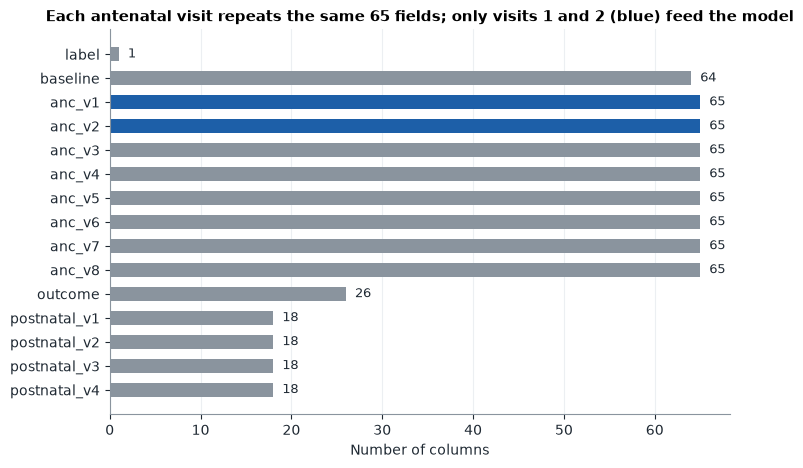

In [8]:
block_order = (["label", "baseline"] + [f"anc_v{k}" for k in range(1, 9)] + ["outcome"]
               + [f"postnatal_v{k}" for k in range(1, 5)])
sizes = block_sizes.reindex(block_order)
colours = [BLUE if b in ("anc_v1", "anc_v2") else GREY for b in sizes.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sizes.index[::-1], sizes.values[::-1], color=colours[::-1], height=0.6)
for y, value in enumerate(sizes.values[::-1]):
    ax.text(value + 1, y, str(value), va="center", fontsize=9, color=INK)
ax.set_xlabel("Number of columns")
ax.set_title("Each antenatal visit repeats the same 65 fields; only visits 1 and 2 (blue) feed the model")
ax.grid(axis="y", visible=False)
save_fig(fig, "fig02_block_sizes")

Figure 2. Number of columns in each block of the raw file. Blue marks the two antenatal visits used for prediction.

### Interpretation

The 683 columns split into 64 baseline columns, eight antenatal visit blocks of 65 fields each, 26 delivery record columns, four postnatal blocks of 18 fields each and the `Risk` label. The eight visit blocks ask the same 65 questions; four field names are simply spelled longer at visit 1, and they line up once that is allowed for. There is no visit date, no facility or district identifier and no mother identifier anywhere in the file. This means gestational age must come from `pregnant_week_number_vk`, results cannot be grouped or checked by site, repeat pregnancies of the same woman cannot be detected, and the serial number (SN) is the only stand in for time. Decision: the model may use only the baseline, visit 1 and visit 2 blocks, and SN order is used as the time proxy for validation.

## Section 3. Type and sentinel audit

Many fields that should hold numbers also contain words such as "no" or "not_checked". These words stand for "no measurement", so they must become missing values, not zeros. Here we find every such word, collect them in `CONFIG["sentinels"]`, and write four small helper functions that every later section uses to read the data in the same way.

In [9]:
def norm_text(series):
    """Lower case and strip text values; leave numbers and missing values unchanged."""
    return series.map(lambda v: v.strip().lower() if isinstance(v, str) else v)


def numeric_share(series):
    """Share of non missing values that already parse as numbers."""
    values = series.dropna()
    if len(values) == 0:
        return 0.0
    return pd.to_numeric(values, errors="coerce").notna().mean()


token_rows = []
for c in columns:
    if pd.api.types.is_numeric_dtype(raw[c]):
        continue
    if numeric_share(raw[c]) < 0.5:
        continue
    text = norm_text(raw[c])
    bad = text[text.notna() & pd.to_numeric(raw[c], errors="coerce").isna()]
    for token, count in bad.value_counts().items():
        token_rows.append({"column": c, "block": BLOCK[c], "token": token, "rows": count})
tokens = pd.DataFrame(token_rows)
token_totals = tokens.groupby("token")["rows"].sum().sort_values(ascending=False)
print(f"{tokens['column'].nunique()} mostly numeric text columns contain {len(token_totals)} distinct non numeric tokens.")
print("Most frequent tokens:")
print(token_totals.head(25).to_string())

32 mostly numeric text columns contain 65 distinct non numeric tokens.
Most frequent tokens:
token
not_checked                 19313
normal                       1983
not checked                  1631
nomal                        1043
no                            542
negative                      458
36.5.                          16
36.6.                          13
36.0.                           7
36.8.                           7
36.7.                           6
12..4                           5
36.2.                           5
post pertum haermorrhage        5
11.3.                           4
37.2.                           4
37.1.                           4
normally                        3
o                               3
36.9.                           3
nil                             3
11.8.9                          3
na                              2
not taken                       2
not tested                      2


In [10]:
found_sentinels = {t for t in token_totals.index if re.match(CONFIG["sentinel_pattern"], t)}
CONFIG["sentinels"] = CONFIG["sentinels"] | found_sentinels
print("Sentinels added from the audit:", sorted(found_sentinels - {"no", "not_checked", "not applicable"}))
print("Final sentinel set:", sorted(CONFIG["sentinels"]))

malformed = [t for t in token_totals.index if re.fullmatch(r"[\d.]+", t)]
print(f"\nMalformed numbers such as '36.5.' or '12..4' ({len(malformed)} distinct tokens) are repaired by to_num where the meaning is unambiguous.")
save_table(tokens.sort_values(["column", "rows"], ascending=[True, False]), "tab03b_non_numeric_tokens")

Sentinels added from the audit: ['na', 'nil', 'not applied', 'not checked', 'not checkedt', 'not measured', 'not taken', 'not tested']
Final sentinel set: ['', 'invalid', 'n/r', 'na', 'nil', 'no', 'none', 'not applicable', 'not applied', 'not checked', 'not checkedt', 'not measured', 'not taken', 'not tested', 'not_checked', 'unknown']

Malformed numbers such as '36.5.' or '12..4' (28 distinct tokens) are repaired by to_num where the meaning is unambiguous.


,column,block,token,rows
9,blood_sugar_result_v1,anc_v1,negative,361
25,blood_sugar_result_v2,anc_v2,negative,38
33,blood_sugar_result_v3,anc_v3,negative,21
38,blood_sugar_result_v4,anc_v4,negative,20
43,blood_sugar_result_v5,anc_v5,negative,9
...,...,...,...,...
99,temperature_v2_p,postnatal_v2,not checked,62
100,temperature_v3_p,postnatal_v3,not checked,461
101,temperature_v3_p,postnatal_v3,minute,1
102,temperature_v4_p,postnatal_v4,not checked,596


In [11]:
def to_num(series, sentinels=None):
    """Convert a field to numbers.

    Sentinel words (CONFIG["sentinels"]) become missing. A trailing full stop and a
    doubled full stop are repaired ("36.5." to 36.5 and "12..4" to 12.4). Anything else
    that is not a number becomes missing. Returns a float Series with the same index.
    """
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    sentinels = CONFIG["sentinels"] if sentinels is None else sentinels
    text = norm_text(series)
    text = text.where(~text.isin(sentinels))
    text = text.map(lambda v: re.sub(r"\.$", "", re.sub(r"\.{2,}", ".", v)) if isinstance(v, str) else v)
    return pd.to_numeric(text, errors="coerce").astype(float)


def parse_bp(series):
    """Split a "systolic/diastolic" blood pressure string into two float columns.

    Values that do not have the form 120/80 (for example "not_checked" or "invalid")
    become missing in both columns.
    """
    parts = norm_text(series).str.extract(r"^(\d{2,3})\s*/\s*(\d{2,3})$")
    return pd.DataFrame({"systolic": parts[0].astype(float), "diastolic": parts[1].astype(float)},
                        index=series.index)


def yes_no(series):
    """Map "yes" to 1 and "no" to 0. Anything else, including missing, becomes NaN."""
    return norm_text(series).map({"yes": 1.0, "no": 0.0}).astype(float)


def normalise_result(series, mapping):
    """Standardise a test result using a spelling mapping.

    Known spellings are mapped to their standard value, other non missing values become
    "other", and missing values stay missing.
    """
    text = norm_text(series)
    mapped = text.map(mapping)
    return mapped.where(text.isna() | mapped.notna(), "other")

In [12]:
# Unit tests for the helpers. Each line must pass before the audit continues.
_t = pd.Series(["60", "no", "not_checked", " 36.5. ", "12..4", "11.8.9", None, "abc", ""])
_r = to_num(_t)
assert _r.iloc[0] == 60 and _r.iloc[3] == 36.5 and _r.iloc[4] == 12.4
assert _r.iloc[[1, 2, 5, 6, 7, 8]].isna().all()
assert to_num(pd.Series([1, 2, 3])).dtype == float

_bp = parse_bp(pd.Series(["120/80", "110 / 70", "not_checked", "invalid", None, "1200/80"]))
assert _bp.iloc[0].tolist() == [120.0, 80.0] and _bp.iloc[1].tolist() == [110.0, 70.0]
assert _bp.iloc[2:].isna().all().all()

_yn = yes_no(pd.Series(["yes", "No ", "maybe", None]))
assert _yn.iloc[0] == 1 and _yn.iloc[1] == 0 and _yn.iloc[2:].isna().all()

_res = normalise_result(pd.Series(["Negative", "ngative", "p0sitive", "rh+", None, "megative"]),
                        CONFIG["result_mapping"])
assert _res.tolist()[:4] == ["negative", "negative", "positive", "other"]
assert pd.isna(_res.iloc[4]) and _res.iloc[5] == "negative"
print("All helper tests passed.")

All helper tests passed.


In [13]:
# Facts quoted in the manifesto about the raw types.
booking_weight_text = norm_text(raw["weight_kg"])
n_weight_no = int((booking_weight_text == "no").sum())
n_fm_no = int((norm_text(raw["date_of_first_foetal_movement_v1"]) == "no").sum())
bp_tokens = {k: norm_text(raw[f"blood_pressure_v{k}"]).value_counts() for k in (1, 2)}

print(f"Booking weight_kg contains 'no' in {n_weight_no} rows")
for k in (1, 2, 3):
    print(f"hemoglobin_check_result_v{k} is stored as {raw[f'hemoglobin_check_result_v{k}'].dtype}")
print(f"date_of_first_foetal_movement_v1 contains 'no' in {n_fm_no} rows")
for k in (1, 2):
    print(f"blood_pressure_v{k}: 'not_checked' {bp_tokens[k]['not_checked']}, 'invalid' {bp_tokens[k]['invalid']}")

assert n_weight_no == 411
assert pd.api.types.is_numeric_dtype(raw["hemoglobin_check_result_v1"])
assert not pd.api.types.is_numeric_dtype(raw["hemoglobin_check_result_v2"])
assert not pd.api.types.is_numeric_dtype(raw["hemoglobin_check_result_v3"])
assert n_fm_no == 4518
assert bp_tokens[1]["not_checked"] == 65 and bp_tokens[2]["not_checked"] == 76
assert bp_tokens[1]["invalid"] == 40 and bp_tokens[2]["invalid"] == 31

Booking weight_kg contains 'no' in 411 rows
hemoglobin_check_result_v1 is stored as float64
hemoglobin_check_result_v2 is stored as str
hemoglobin_check_result_v3 is stored as str
date_of_first_foetal_movement_v1 contains 'no' in 4518 rows
blood_pressure_v1: 'not_checked' 65, 'invalid' 40
blood_pressure_v2: 'not_checked' 76, 'invalid' 31


In [14]:
mapping_rows = []
for family in ["malaria_rapid_test_result", "urine_glucose_check_result"]:
    values = pd.concat([norm_text(raw[f"{family}_v{k}"]) for k in range(1, 9)]).dropna()
    for raw_value, count in values.value_counts().items():
        mapping_rows.append({
            "field_family": family,
            "raw_value": raw_value,
            "standard_value": CONFIG["result_mapping"].get(raw_value, "other"),
            "rows_all_visits": count,
        })
result_mappings = save_table(pd.DataFrame(mapping_rows), "tab03_result_mappings")
result_mappings

,field_family,raw_value,standard_value,rows_all_visits
0,malaria_rapid_test_result,negative,negative,10440
1,malaria_rapid_test_result,ngative,negative,36
2,malaria_rapid_test_result,p0sitive,positive,28
3,malaria_rapid_test_result,positive,positive,26
4,malaria_rapid_test_result,nergative,negative,5
5,malaria_rapid_test_result,negastive,negative,3
6,malaria_rapid_test_result,nevative,negative,2
7,malaria_rapid_test_result,rh+,other,1
8,malaria_rapid_test_result,ngativeno,other,1
9,malaria_rapid_test_result,negstav,other,1


### Interpretation

Thirty two mostly numeric text columns contain 65 different non numeric tokens; "not_checked" alone appears 19,313 times. We confirmed every fact quoted in the brief: booking `weight_kg` holds "no" in 411 rows, visit 1 haemoglobin is stored as numbers while visits 2 and 3 are text, `date_of_first_foetal_movement_v1` holds "no" in 4,518 rows, and blood pressure is a "systolic/diastolic" string with "not_checked" and "invalid" entries. Eight new missing value markers (such as "not tested" and "nil") were added to the sentinel list, and malformed numbers like "36.5." are repaired rather than thrown away. The malaria mapping turns 36 "ngative" and 28 "p0sitive" entries into proper results; a few rare spellings such as "neg" in urine glucose go to "other" as the rule requires, which does not matter because urine glucose is not a model feature. Decision: every later section reads numbers only through `to_num`, `parse_bp`, `yes_no` and `normalise_result`, so the whole notebook treats "no measurement" the same way.

## Section 4. Outcome audit

The outcome is the baby's birth weight in kilograms (`newborn_birth_weight_kg_`). Low birth weight (LBW) means a weight below 2.5 kg, the World Health Organization definition. Before trusting it we check how complete it is, whether the values are plausible, whether staff rounded weights to convenient numbers, and how LBW lines up with other delivery facts.

In [15]:
OUTCOME = CONFIG["outcome_column"]
LBW_CUT = CONFIG["lbw_threshold_kg"]
BW_LOW, BW_HIGH = CONFIG["bw_bounds"]

bw = raw[OUTCOME].astype(float)
lbw_raw = (bw < LBW_CUT).astype(int)
sn_block = pd.qcut(raw["SN"], CONFIG["sn_blocks"], labels=range(1, CONFIG["sn_blocks"] + 1)).astype(int)

outcome_facts = {
    "non_null": int(bw.notna().sum()),
    "lbw_rows": int(lbw_raw.sum()),
    "lbw_percent": round(lbw_raw.mean() * 100, 2),
    "above_upper_bound": int((bw > BW_HIGH).sum()),
    "below_lower_bound": int((bw < BW_LOW).sum()),
    "maximum": float(bw.max()),
    "minimum": float(bw.min()),
    "share_at_3_0_kg": round((bw == 3.0).mean() * 100, 1),
}
print(json.dumps(outcome_facts, indent=2))
print("\nValues above 6.0 kg:", sorted(bw[bw > BW_HIGH].unique().tolist()))

assert outcome_facts["non_null"] == 8817
assert outcome_facts["lbw_rows"] == 443 and outcome_facts["lbw_percent"] == 5.02
assert outcome_facts["above_upper_bound"] == 35
assert outcome_facts["maximum"] == 500
MANIFEST["outcome"] = outcome_facts

{
  "non_null": 8817,
  "lbw_rows": 443,
  "lbw_percent": 5.02,
  "above_upper_bound": 35,
  "below_lower_bound": 0,
  "maximum": 500.0,
  "minimum": 1.0,
  "share_at_3_0_kg": 13.6
}

Values above 6.0 kg: [8.0, 9.7, 12.2, 23.1, 32.0, 33.0, 34.0, 35.0, 37.2, 37.3, 50.0, 52.0, 53.0, 54.0, 55.0, 56.0, 58.0, 59.0, 61.0, 64.0, 68.0, 69.0, 76.0, 500.0]


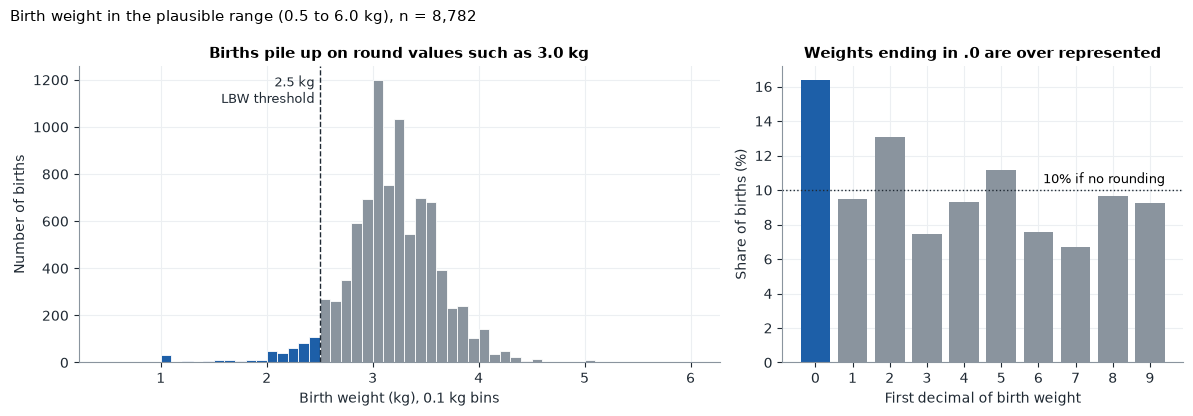

In [16]:
plausible = bw[(bw >= BW_LOW) & (bw <= BW_HIGH)]
first_decimal = (np.round(plausible * 10) % 10).astype(int)
decimal_share = first_decimal.value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
bins = np.arange(BW_LOW, BW_HIGH + 0.1, 0.1)
counts, edges, patches = axes[0].hist(plausible, bins=bins, color=GREY, edgecolor="white", linewidth=0.6)
for patch, left in zip(patches, edges[:-1]):
    if left < LBW_CUT - 1e-9:
        patch.set_facecolor(BLUE)
axes[0].axvline(LBW_CUT, color=INK, linestyle="--", linewidth=1)
axes[0].text(LBW_CUT - 0.05, counts.max() * 0.92, "2.5 kg\nLBW threshold", ha="right", fontsize=9, color=INK)
axes[0].set_xlabel("Birth weight (kg), 0.1 kg bins")
axes[0].set_ylabel("Number of births")
axes[0].set_title("Births pile up on round values such as 3.0 kg")

axes[1].bar(decimal_share.index, decimal_share.values, color=[BLUE if d == 0 else GREY for d in decimal_share.index])
axes[1].axhline(10, color=INK, linestyle=":", linewidth=1)
axes[1].text(9.4, 10.4, "10% if no rounding", ha="right", fontsize=9)
axes[1].set_xticks(range(10))
axes[1].set_xlabel("First decimal of birth weight")
axes[1].set_ylabel("Share of births (%)")
axes[1].set_title("Weights ending in .0 are over represented")
fig.suptitle(f"Birth weight in the plausible range ({BW_LOW} to {BW_HIGH} kg), n = {len(plausible):,}", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save_fig(fig, "fig03_birth_weight")

Figure 3. Left: distribution of birth weight with LBW births in blue and the 2.5 kg threshold dashed. Right: share of births by the first decimal of the recorded weight. Without rounding each digit would hold about 10 percent.

In [17]:
def lbw_rate_table(groups, name):
    out = (pd.DataFrame({"group": groups.astype(str), "lbw": lbw_raw})
           .groupby("group")["lbw"].agg(n="size", n_lbw="sum").reset_index())
    out.insert(0, "variable", name)
    out["lbw_rate_percent"] = (out["n_lbw"] / out["n"] * 100).round(1)
    ci = [wilson(r.n_lbw, r.n) for r in out.itertuples()]
    out["ci_low_percent"] = [round(lo * 100, 1) for lo, _ in ci]
    out["ci_high_percent"] = [round(hi * 100, 1) for _, hi in ci]
    return out


crosstab_parts = [lbw_rate_table(raw[c], c) for c in
                  ["preterm_labour", "still_births", "live_births", "twins_delivery", "mode_of_delivery", "Risk"]]
crosstab_parts.append(lbw_rate_table(sn_block.astype(str).str.zfill(2), "SN decile"))
outcome_crosstabs = save_table(pd.concat(crosstab_parts, ignore_index=True), "tab04_outcome_crosstabs")


def rate(variable, group):
    row = outcome_crosstabs[(outcome_crosstabs.variable == variable) & (outcome_crosstabs.group == group)]
    return float(row["lbw_rate_percent"].iloc[0])


assert rate("preterm_labour", "yes") == 47.5
assert rate("still_births", "yes") == 30.8
assert rate("twins_delivery", "yes") == 5.2 and rate("twins_delivery", "no") == 5.0
assert rate("Risk", "high") == 4.8 and rate("Risk", "low") == 5.4
decile_rates = outcome_crosstabs.loc[outcome_crosstabs.variable == "SN decile", "lbw_rate_percent"]
assert decile_rates.min() == 3.3 and decile_rates.max() == 6.6
outcome_crosstabs

,variable,group,n,n_lbw,lbw_rate_percent,ci_low_percent,ci_high_percent
0,preterm_labour,no,8459,273,3.2,2.9,3.6
1,preterm_labour,yes,358,170,47.5,42.4,52.7
2,still_births,no,8687,403,4.6,4.2,5.1
3,still_births,yes,130,40,30.8,23.5,39.2
4,live_births,no,208,61,29.3,23.6,35.8
5,live_births,yes,8609,382,4.4,4.0,4.9
6,twins_delivery,no,8394,421,5.0,4.6,5.5
7,twins_delivery,yes,423,22,5.2,3.5,7.7
8,mode_of_delivery,c-section,1280,69,5.4,4.3,6.8
9,mode_of_delivery,forceps,1,1,100.0,20.7,100.0


In [18]:
complication = norm_text(raw["new_born_with_complication"]).fillna("")
text_lbw = complication.str.contains("low birth") | complication.str.contains("lbw")
n_text_lbw = int(text_lbw.sum())
n_text_and_numeric = int((text_lbw & (lbw_raw == 1)).sum())
n_text_only = n_text_lbw - n_text_and_numeric
n_numeric_only = int(((lbw_raw == 1) & ~text_lbw).sum())

print(f"Complication text mentions low birth weight: {n_text_lbw} rows")
print(f"  of which the recorded weight is below 2.5 kg: {n_text_and_numeric}")
print(f"  of which the recorded weight is 2.5 kg or more: {n_text_only}")
print(f"Recorded weight below 2.5 kg with no LBW text: {n_numeric_only} of {lbw_raw.sum()}")
print("\nRecorded weights of the text only cases:")
print(bw[text_lbw & (lbw_raw == 0)].describe().round(2).to_string())

assert n_text_lbw == 128 and n_text_and_numeric == 67
MANIFEST["outcome"].update({"complication_text_lbw": n_text_lbw, "complication_text_and_weight_lbw": n_text_and_numeric})

Complication text mentions low birth weight: 128 rows
  of which the recorded weight is below 2.5 kg: 67
  of which the recorded weight is 2.5 kg or more: 61
Recorded weight below 2.5 kg with no LBW text: 376 of 443

Recorded weights of the text only cases:
count    61.00
mean      4.02
std       6.78
min       2.50
25%       3.00
50%       3.10
75%       3.40
max      56.00


### Interpretation

Birth weight is recorded for all 8,817 pregnancies and 443 (5.02 percent) are below 2.5 kg. Thirty five values are above 6.0 kg, up to 500, which are almost certainly grams or typing errors, and they are removed in Section 8. The outcome behaves as it should clinically: 47.5 percent of preterm births and 30.8 percent of stillbirths are LBW. Two things need care. First, recorded weights pile up on round numbers: 1,198 babies (13.6 percent) weigh exactly 3.0 kg and 268 sit exactly on 2.5 kg, where they count as not LBW, so a small change in rounding habits could move babies across the threshold. Second, twins have almost the same LBW rate as singletons (5.2 versus 5.0 percent) when twins normally have a much higher rate, which suggests `twins_delivery` or the twin weights are unreliable; twins are excluded in Section 8 in any case. The `Risk` column is not an LBW label (4.8 percent LBW among "high" against 5.4 percent among "low"), the free text complication field agrees with the weight in only 67 of its 128 LBW mentions, and the LBW rate drifts from 3.3 to 6.6 percent across SN deciles. Decision: the outcome is the numeric weight below 2.5 kg; the text field and `Risk` are never used, and the drift over SN supports a temporal check of the model.

## Section 5. Visit availability and timing

The study idea is to predict LBW from the first two antenatal visits. That only works for women who attended two visits, and it is only useful if the second visit happens early enough to act on. This section counts how many women have each visit, looks at when the visits happen in pregnancy, and shows how the choice of a gestational age cutoff changes the size of the cohort.

There are no visit dates in the file. Timing comes from the gestational week recorded at each visit (`pregnant_week_number_vk`).

In [19]:
availability_rows = []
block_present = {}
for k in range(1, 9):
    block_present[k] = raw[block_columns(f"anc_v{k}")].notna().any(axis=1)
    measured = raw[f"weight_kg_v{k}"].notna() & raw[f"pregnant_week_number_v{k}"].notna()
    availability_rows.append({"visit": k, "any_field_populated": int(block_present[k].sum()),
                              "weight_and_week_present": int(measured.sum())})
visit_availability = pd.DataFrame(availability_rows)
print(visit_availability.to_string(index=False))

assert visit_availability.loc[0, "any_field_populated"] == 8817 and visit_availability.loc[1, "any_field_populated"] == 6934
assert visit_availability.loc[0, "weight_and_week_present"] == 8762 and visit_availability.loc[1, "weight_and_week_present"] == 6844
MANIFEST["visit_availability"] = visit_availability.to_dict(orient="records")

 visit  any_field_populated  weight_and_week_present
     1                 8817                     8762
     2                 6934                     6844
     3                 5157                     5087
     4                 3021                     2984
     5                 1651                     1616
     6                  677                      668
     7                  174                      174
     8                   42                       42


In [20]:
populated_blocks = sum(block_present[k].astype(int) for k in range(1, 9))
visit_crosstab = pd.crosstab(raw["total_antenatal_visits"], populated_blocks,
                             rownames=["total_antenatal_visits (recorded)"], colnames=["visit blocks populated"])
n_visit_disagree = int((populated_blocks != raw["total_antenatal_visits"]).sum())
print(visit_crosstab.to_string())
print(f"\nRows where the recorded total disagrees with the populated blocks: {n_visit_disagree}")
assert n_visit_disagree == 301
MANIFEST["visit_count_disagreements"] = n_visit_disagree

visit blocks populated                1     2     3     4    5    6    7   8
total_antenatal_visits (recorded)                                           
0                                     3     2     1     2    0    0    0   0
1                                  1730    21     7     2    0    0    1   0
2                                    40  1695     6     3    1    0    0   0
3                                    46    18  2111     3    1    2    0   0
4                                    26    17     5  1357    0    1    0   0
5                                    23    16     4     3  962    0    0   0
6                                    10     8     2     0   10  497    0   0
7                                     3     0     0     0    0    3  128   0
8                                     2     0     0     0    0    0    3  36
9                                     0     0     0     0    0    0    0   6

Rows where the recorded total disagrees with the populated blocks: 301


In [21]:
ga1 = raw["pregnant_week_number_v1"].astype(float)
ga2 = raw["pregnant_week_number_v2"].astype(float)
gap = ga2 - ga1


def median_iqr(series):
    q = series.dropna().quantile([0.25, 0.5, 0.75])
    return float(q[0.5]), float(q[0.25]), float(q[0.75])


timing = {"ga_v1": median_iqr(ga1), "ga_v2": median_iqr(ga2), "gap_weeks": median_iqr(gap)}
n_ga_not_increasing = int((gap <= 0).sum())
for name, (med, lo, hi) in timing.items():
    print(f"{name:<10} median {med:g} (IQR {lo:g} to {hi:g})")
print(f"Rows with GA at visit 2 not greater than GA at visit 1: {n_ga_not_increasing}")

assert timing["ga_v1"] == (21, 16, 27) and timing["ga_v2"] == (26, 22, 31) and timing["gap_weeks"] == (5, 4, 7)
assert n_ga_not_increasing == 152
MANIFEST["timing"] = {k: {"median": v[0], "q1": v[1], "q3": v[2]} for k, v in timing.items()}
MANIFEST["timing"]["ga_v2_not_greater_than_ga_v1"] = n_ga_not_increasing

ga_v1      median 21 (IQR 16 to 27)
ga_v2      median 26 (IQR 22 to 31)
gap_weeks  median 5 (IQR 4 to 7)
Rows with GA at visit 2 not greater than GA at visit 1: 152


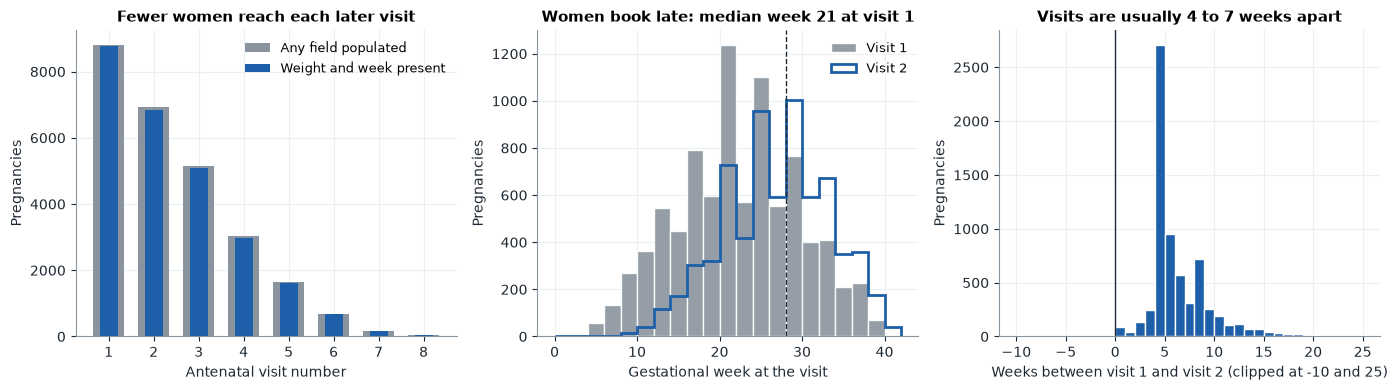

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(visit_availability["visit"], visit_availability["any_field_populated"], color=GREY, width=0.7, label="Any field populated")
axes[0].bar(visit_availability["visit"], visit_availability["weight_and_week_present"], color=BLUE, width=0.4, label="Weight and week present")
axes[0].set_xlabel("Antenatal visit number")
axes[0].set_ylabel("Pregnancies")
axes[0].set_title("Fewer women reach each later visit")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_xticks(range(1, 9))

week_bins = np.arange(0, 44, 2)
axes[1].hist(ga1.dropna(), bins=week_bins, color=GREY, alpha=0.9, label="Visit 1", edgecolor="white")
axes[1].hist(ga2.dropna(), bins=week_bins, histtype="step", color=BLUE, linewidth=2, label="Visit 2")
axes[1].axvline(28, color=INK, linestyle="--", linewidth=1)
axes[1].set_xlabel("Gestational week at the visit")
axes[1].set_ylabel("Pregnancies")
axes[1].set_title("Women book late: median week 21 at visit 1")
axes[1].legend(fontsize=9)

axes[2].hist(gap.dropna().clip(-10, 25), bins=np.arange(-10, 26, 1), color=BLUE, edgecolor="white")
axes[2].axvline(0, color=INK, linewidth=1)
axes[2].set_xlabel("Weeks between visit 1 and visit 2 (clipped at -10 and 25)")
axes[2].set_ylabel("Pregnancies")
axes[2].set_title("Visits are usually 4 to 7 weeks apart")
fig.tight_layout()
save_fig(fig, "fig04_visit_availability")

Figure 4. Left: pregnancies with each antenatal visit. Middle: gestational week at visit 1 (grey) and visit 2 (blue outline), with the 28 week cutoff dashed. Right: weeks between the two visits; values at or below zero are recording errors.

In [23]:
# Cutoff sensitivity uses every cohort rule except the cutoff itself (see Section 8 for the rules).
duplicate_row = raw.drop(columns="SN").duplicated(keep="first")
base_rule = (~duplicate_row & bw.between(BW_LOW, BW_HIGH)
             & raw["weight_kg_v1"].notna() & ga1.notna()
             & raw["weight_kg_v2"].notna() & ga2.notna()
             & (ga2 > ga1) & (norm_text(raw["twins_delivery"]) == "no"))
cutoff_rows = []
for cutoff in CONFIG["cutoff_grid"]:
    keep = base_rule & (ga2 <= cutoff)
    cutoff_rows.append({"cutoff_week": cutoff, "cohort_n": int(keep.sum()), "lbw_n": int(lbw_raw[keep].sum()),
                        "lbw_percent": round(lbw_raw[keep].mean() * 100, 2)})
cutoff_table = save_table(pd.DataFrame(cutoff_rows), "tab05_cutoff_sensitivity")
cutoff_table

,cutoff_week,cohort_n,lbw_n,lbw_percent
0,24,2642,186,7.04
1,28,4167,260,6.24
2,32,5392,301,5.58
3,36,6101,328,5.38


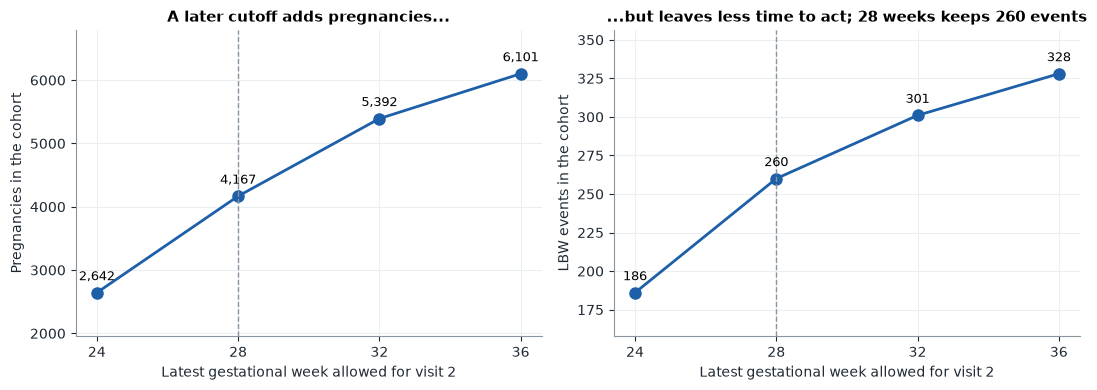

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column, label in [(axes[0], "cohort_n", "Pregnancies in the cohort"), (axes[1], "lbw_n", "LBW events in the cohort")]:
    ax.plot(cutoff_table["cutoff_week"], cutoff_table[column], color=BLUE, marker="o", linewidth=2, markersize=8)
    for x, y in zip(cutoff_table["cutoff_week"], cutoff_table[column]):
        ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
    ax.axvline(CONFIG["ga_cutoff_primary"], color=GREY, linestyle="--", linewidth=1)
    ax.set_xticks(CONFIG["cutoff_grid"])
    ax.set_xlabel("Latest gestational week allowed for visit 2")
    ax.set_ylabel(label)
    ax.margins(y=0.2)
axes[0].set_title("A later cutoff adds pregnancies...")
axes[1].set_title("...but leaves less time to act; 28 weeks keeps 260 events")
fig.tight_layout()
save_fig(fig, "fig05_cutoff_tradeoff")

Figure 5. Cohort size (left) and number of LBW events (right) when visit 2 must happen by 24, 28, 32 or 36 weeks. The dashed line marks the primary cutoff of 28 weeks.

booking_band    n  lbw_n  lbw_percent  ci_low  ci_high
     1 to 12 1194     86          7.2     5.9      8.8
    13 to 20 2954    187          6.3     5.5      7.3
    21 to 28 3103    134          4.3     3.7      5.1
    above 28 1511     35          2.3     1.7      3.2


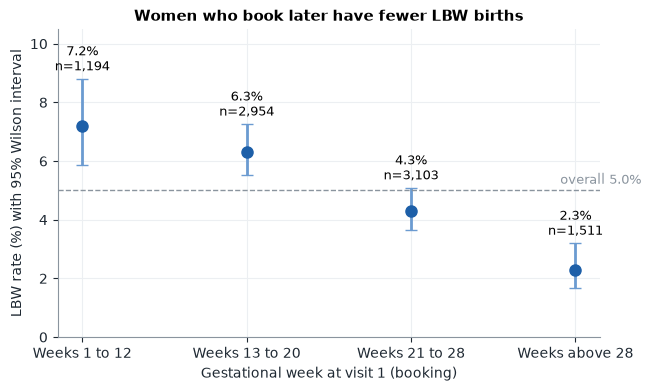

In [25]:
band_cfg = CONFIG["booking_week_bands"]
booking_band = pd.cut(ga1, band_cfg["edges"], labels=band_cfg["labels"])
band_rows = []
for band in band_cfg["labels"]:
    in_band = booking_band == band
    n, events = int(in_band.sum()), int(lbw_raw[in_band].sum())
    lo, hi = wilson(events, n)
    band_rows.append({"booking_band": band, "n": n, "lbw_n": events, "lbw_percent": round(events / n * 100, 1),
                      "ci_low": lo * 100, "ci_high": hi * 100})
booking_rates = pd.DataFrame(band_rows)
print(booking_rates.round(1).to_string(index=False))
assert booking_rates["lbw_percent"].tolist() == [7.2, 6.3, 4.3, 2.3]
MANIFEST["lbw_by_booking_band"] = booking_rates.round(2).to_dict(orient="records")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(booking_rates))
ax.errorbar(x, booking_rates["lbw_percent"],
            yerr=[booking_rates["lbw_percent"] - booking_rates["ci_low"], booking_rates["ci_high"] - booking_rates["lbw_percent"]],
            fmt="o", color=BLUE, ecolor=MID_BLUE, elinewidth=2, capsize=4, markersize=8)
for xi, r in zip(x, booking_rates.itertuples()):
    ax.annotate(f"{r.lbw_percent:.1f}%\nn={r.n:,}", (xi, r.ci_high), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.axhline(lbw_raw.mean() * 100, color=GREY, linestyle="--", linewidth=1)
ax.text(len(x) - 0.6, lbw_raw.mean() * 100 + 0.2, "overall 5.0%", ha="right", fontsize=9, color=GREY)
ax.set_xticks(x, [f"Weeks {b}" for b in booking_rates["booking_band"]])
ax.set_xlabel("Gestational week at visit 1 (booking)")
ax.set_ylabel("LBW rate (%) with 95% Wilson interval")
ax.set_ylim(0, 10.5)
ax.set_title("Women who book later have fewer LBW births")
save_fig(fig, "fig06_lbw_by_booking_week")

Figure 6. LBW rate by gestational week at the first visit, all pregnancies with a recorded booking week (n = 8,762). Bars show 95 percent Wilson intervals; the dashed line is the overall rate.

### Interpretation

All 8,817 pregnancies have a first visit, 6,934 have something recorded for a second visit and 6,844 have a second visit weight and gestational week. The recorded `total_antenatal_visits` disagrees with the visit blocks actually filled in for 301 women, so the populated blocks are treated as the truth. Women book late (median week 21, IQR 16 to 27) and come back about five weeks later (median week 26 at visit 2), and in 152 records the second visit is not later than the first, which must be a recording error. The cutoff table shows the trade off: allowing visit 2 up to 28 weeks gives 4,167 pregnancies with 260 LBW births, while 32 weeks gives 5,392 with 301 but leaves less time to act. LBW falls from 7.2 percent among women who book by week 12 to 2.3 percent among those who book after week 28; this is partly because a baby born very early cannot belong to a mother who books late, so booking week indirectly carries information about pregnancy length. Decision: the primary cohort uses visit 2 at or before 28 weeks, with 32 weeks as the sensitivity analysis, and booking week stays as a predictor because it is genuinely known at visit 1.

## Section 6. Leakage audit

Leakage happens when a predictor secretly contains the answer. A field that looks like history taken at booking but was actually filled in after delivery would make the model look excellent on paper and useless in a clinic. We test every baseline, visit 1 and visit 2 field in two ways:

1. Agreement with a delivery record field of the same type. For yes or no fields we also compute Cohen's kappa, which corrects for chance. Without it, any two rare fields agree more than 95 percent of the time simply because both are almost always "no".
2. The LBW rate among women in the positive class. A history field whose positive class has an LBW rate above 30 percent, six times the base rate, is far more predictive than any real booking fact should be.

One field, `miscarriages_or_abortions_1`, is labelled like booking history but sits inside the delivery record in the file. We add such fields (a booking field name followed by `_1`) to the audit so they are tested like any other history field.

A field is flagged if its agreement is above 95 percent with a kappa of at least 0.6, or if its positive class (at least 20 women) has an LBW rate above 30 percent.

In [26]:
outcome_cols = [c for c in columns if BLOCK[c] == "outcome" and not c.startswith("visit_number")]
# Fields inside the delivery record that are named like booking history (a booking field name plus "_1").
history_like = [c for c in outcome_cols if c.endswith("_1") and c[:-2] in columns]
candidate_cols = [c for c in columns if BLOCK[c] in ("baseline", "anc_v1", "anc_v2") and c != "SN"] + history_like
print("History style fields found inside the delivery record and added to the audit:", history_like)
text_cache = {c: norm_text(raw[c]) for c in candidate_cols + outcome_cols}


def field_kind(c):
    if pd.api.types.is_numeric_dtype(raw[c]):
        return "numeric"
    values = set(text_cache[c].dropna().unique())
    return "binary" if values and values <= {"yes", "no"} else "categorical"


def cohen_kappa(a, b):
    po = (a == b).mean()
    pe = sum((a == v).mean() * (b == v).mean() for v in set(a) | set(b))
    return (po - pe) / (1 - pe) if pe < 1 else np.nan


kinds = {c: field_kind(c) for c in candidate_cols + outcome_cols}
outcome_by_kind = {k: [c for c in outcome_cols if kinds[c] == k] for k in ("binary", "numeric")}

leak_rows = []
for c in candidate_cols:
    kind = kinds[c]
    best = {"outcome_match": None, "agreement": np.nan, "kappa": np.nan}
    if kind in ("binary", "numeric"):
        for o in [o for o in outcome_by_kind[kind] if o != c]:
            a, b = (text_cache[c], text_cache[o]) if kind == "binary" else (raw[c], raw[o])
            both = a.notna() & b.notna()
            if both.sum() == 0:
                continue
            agreement = float((a[both] == b[both]).mean())
            if np.isnan(best["agreement"]) or agreement > best["agreement"]:
                kappa = cohen_kappa(a[both].to_numpy(), b[both].to_numpy()) if kind == "binary" else np.nan
                best = {"outcome_match": o, "agreement": agreement, "kappa": kappa}
    positive_level, positive_n, positive_rate = None, 0, np.nan
    text = text_cache[c]
    if kind == "binary":
        positive_level = "yes"
    elif kind == "categorical" and text.nunique() <= CONFIG["leakage_max_levels"]:
        counts = text.value_counts()
        eligible = [lvl for lvl in counts.index[1:] if counts[lvl] >= CONFIG["leakage_min_class_n"]]
        if eligible:
            positive_level = max(eligible, key=lambda lvl: lbw_raw[text == lvl].mean())
    if positive_level is not None:
        in_class = text == positive_level
        positive_n = int(in_class.sum())
        positive_rate = float(lbw_raw[in_class].mean()) if positive_n else np.nan
    leak_rows.append({"field": c, "block": BLOCK[c], "kind": kind, **best,
                      "positive_class": positive_level, "positive_n": positive_n, "positive_lbw_rate": positive_rate})

leakage = pd.DataFrame(leak_rows)
by_agreement = (leakage["agreement"] > CONFIG["leakage_agreement"]) & (
    (leakage["kind"] == "numeric") | (leakage["kappa"] >= CONFIG["leakage_kappa_min"]))
by_rate = (leakage["positive_lbw_rate"] > CONFIG["leakage_lbw_rate"]) & (leakage["positive_n"] >= CONFIG["leakage_min_class_n"])
leakage["flag_agreement"] = by_agreement
leakage["flag_lbw_rate"] = by_rate
leakage["leakage_flag"] = by_agreement | by_rate
flagged = leakage[leakage["leakage_flag"]]
print(f"Fields audited: {len(leakage)}; flagged: {len(flagged)}")
flagged.round(3)

History style fields found inside the delivery record and added to the audit: ['miscarriages_or_abortions_1']


Fields audited: 194; flagged: 3


,field,block,kind,outcome_match,agreement,kappa,positive_class,positive_n,positive_lbw_rate,flag_agreement,flag_lbw_rate,leakage_flag
15,labour_at_term_1,baseline,binary,labour_at_term,0.967,0.718,yes,8133,0.029,True,False,True
16,preterm_labour_1,baseline,binary,preterm_labour,0.999,0.987,yes,349,0.487,True,True,True
193,miscarriages_or_abortions_1,outcome,binary,bleeding_during_pregnancy,0.988,0.218,yes,86,0.372,False,True,True


In [27]:
print("Closest outcome matches among unflagged fields (highest agreement first):")
print(leakage[~leakage["leakage_flag"]].sort_values("agreement", ascending=False)
      .head(8)[["field", "outcome_match", "agreement", "kappa", "positive_lbw_rate"]].round(3).to_string(index=False))

print("\npreterm_labour_1 (history) against preterm_labour (delivery):")
print(pd.crosstab(raw["preterm_labour_1"], raw["preterm_labour"], rownames=["history"], colnames=["delivery"]))
ptl_agree = int((text_cache["preterm_labour_1"] == text_cache["preterm_labour"]).sum())
ptl_yes_then_no = int(((text_cache["preterm_labour_1"] == "yes") & (text_cache["preterm_labour"] == "no")).sum())
ptl_rate = leakage.set_index("field").loc["preterm_labour_1", "positive_lbw_rate"]

assert set(flagged["field"]) >= {"preterm_labour_1", "labour_at_term_1", "miscarriages_or_abortions_1"}
assert ptl_agree == 8808 and ptl_yes_then_no == 0 and round(ptl_rate * 100, 1) == 48.7

Closest outcome matches among unflagged fields (highest agreement first):
                          field             outcome_match  agreement  kappa  positive_lbw_rate
                kidney_diseases bleeding_during_pregnancy      0.994 -0.000              0.000
           gestational_diabetes bleeding_during_pregnancy      0.994 -0.001              0.000
                      allergies bleeding_during_pregnancy      0.994 -0.001              0.000
       congenital_malformations bleeding_during_pregnancy      0.994 -0.001              0.143
                   tuberculosis bleeding_during_pregnancy      0.994 -0.001              0.143
                   hypertension bleeding_during_pregnancy      0.994 -0.001              0.000
              diabetes_mellitus bleeding_during_pregnancy      0.994 -0.002              0.125
bleeding_in_previous_puerperium bleeding_during_pregnancy      0.993  0.031              0.250

preterm_labour_1 (history) against preterm_labour (delivery):
delivery

In [28]:
bp_flag_v1 = raw["bp_is_greater_than_140_90_v1"]
bp_parsed_v1 = parse_bp(raw["blood_pressure_v1"])
n_parsed_high_v1 = int(((bp_parsed_v1["systolic"] >= CONFIG["bp_high_systolic"]) |
                        (bp_parsed_v1["diastolic"] >= CONFIG["bp_high_diastolic"])).sum())
print("bp_is_greater_than_140_90_v1 values:", bp_flag_v1.value_counts().to_dict())
print("Parsed visit 1 readings at or above 140/90:", n_parsed_high_v1)
print("bp_is_greater_than_140_90_v2 values:", norm_text(raw["bp_is_greater_than_140_90_v2"]).value_counts().to_dict())
assert (bp_flag_v1 == 0).all() and n_parsed_high_v1 == 90

bp_is_greater_than_140_90_v1 values: {0: 8817}
Parsed visit 1 readings at or above 140/90: 90
bp_is_greater_than_140_90_v2 values: {'not applicable': 6811, 'give antihypertensive': 33}


In [29]:
reasons = {}


def exclude(cols, reason):
    for c in cols:
        reasons.setdefault(c, reason)


exclude(flagged["field"], "Leakage audit: history field that behaves like a delivery outcome")
exclude(block_columns("label"), "Dataset risk label; not an LBW label and assigned with knowledge of the whole record")
exclude([c for c in columns if c.startswith("bp_is_greater_than_140_90_v")],
        "Derived BP flag contradicts the recorded BP (all zero at visit 1 while 90 readings are at or above 140/90)")
exclude(["total_antenatal_visits"], "Counted after delivery; reveals how long the pregnancy lasted")
exclude(block_columns("outcome"), "Delivery record; only known after birth")
for k in range(1, 5):
    exclude(block_columns(f"postnatal_v{k}"), "Postnatal visit; only known after birth")
for k in range(3, 9):
    exclude(block_columns(f"anc_v{k}"), "Antenatal visit after visit 2; outside the two visit prediction window")

CONFIG["never_use"] = sorted(reasons)
excluded_fields = pd.DataFrame({"column": list(reasons), "block": [BLOCK[c] for c in reasons], "reason": list(reasons.values())})
save_table(excluded_fields, "tab06_excluded_fields")
print(f"Columns the model must never use: {len(CONFIG['never_use'])}")
print(excluded_fields["reason"].value_counts().to_string())
MANIFEST["leakage_flagged"] = flagged[["field", "outcome_match", "agreement", "kappa", "positive_lbw_rate"]].round(4).to_dict(orient="records")

Columns the model must never use: 493
reason
Antenatal visit after visit 2; outside the two visit prediction window                                        384
Postnatal visit; only known after birth                                                                        72
Delivery record; only known after birth                                                                        24
Derived BP flag contradicts the recorded BP (all zero at visit 1 while 90 readings are at or above 140/90)      8
Leakage audit: history field that behaves like a delivery outcome                                               3
Dataset risk label; not an LBW label and assigned with knowledge of the whole record                            1
Counted after delivery; reveals how long the pregnancy lasted                                                   1


### Interpretation

We audited 194 candidate fields and three were flagged, exactly the three named in the brief. `preterm_labour_1` agrees with the delivery field `preterm_labour` in 8,808 of 8,817 rows, never says "yes" when delivery says "no", and 48.7 percent of its positive class is LBW, so it is the delivery outcome copied into the history section. `labour_at_term_1` agrees with `labour_at_term` 96.7 percent of the time with a kappa of 0.72, and `miscarriages_or_abortions_1` has an LBW rate of 37.2 percent among its 86 positive cases. The kappa rule matters: fields such as `kidney_diseases` agree with a delivery field 99.4 percent of the time only because both are almost always "no", and their kappa is zero. The derived flag `bp_is_greater_than_140_90_v1` is zero for every woman even though 90 readings are at or above 140/90. Decision: 493 columns go on the never use list (Table 6), including the three leaking fields, the whole delivery and postnatal record, the `Risk` label, the derived BP flags, `total_antenatal_visits` and visits 3 to 8.

## Section 7. Internal consistency audit

A field can be complete and still be wrong. Here we test whether related fields tell the same story: number of pregnancies against number of prior deliveries, twins at booking against twins at delivery, recorded dates against each other, the derived blood pressure flag against the readings themselves, and simple ranges. Each check ends with a decision.

In [30]:
gravidity = raw["no_pregnancy"].astype(float)
prior_deliveries = raw["number_of_prior_deliveries"].astype(float)
consistency = []


def add_check(check, count, denominator, decision):
    consistency.append({"check": check, "count": int(count), "denominator": int(denominator),
                        "percent": round(count / denominator * 100, 1) if denominator else np.nan, "decision": decision})


# 1. Parity
g1 = gravidity == 1
add_check("Gravidity 1 (first pregnancy) but prior deliveries above 0", (g1 & (prior_deliveries > 0)).sum(), g1.sum(),
          "Flag as qc_parity_conflict; keep the rows; run a sensitivity cohort without them")
qc_parity_conflict = prior_deliveries >= gravidity
add_check("Prior deliveries at or above gravidity", qc_parity_conflict.sum(), len(raw),
          "Same flag; gravidity counts the current pregnancy, so prior deliveries must be smaller")
assert (g1 & (prior_deliveries > 0)).sum() == 2001 and g1.sum() == 2392 and qc_parity_conflict.sum() == 4881

# 2. Twins
twin_booked = norm_text(raw["twin_pregnancy"]) == "yes"
twin_delivered = norm_text(raw["twins_delivery"]) == "yes"
add_check("Twin pregnancy recorded at booking", twin_booked.sum(), len(raw), "Not used for exclusion")
add_check("Twin delivery recorded", twin_delivered.sum(), len(raw), "Exclusion uses twins_delivery")
add_check("Twin at booking and twin at delivery", (twin_booked & twin_delivered).sum(), twin_booked.sum(),
          "The two fields barely overlap; booking field kept only as a weak predictor")
assert twin_booked.sum() == 139 and twin_delivered.sum() == 423 and (twin_booked & twin_delivered).sum() == 7

In [31]:
# 3. Dates
lmp = pd.to_datetime(raw["last_normal_menustration_date"], format=CONFIG["date_format"], errors="coerce")
edd = pd.to_datetime(raw["expected_date_of_delivery"], format=CONFIG["date_format"], errors="coerce")
edd_minus_lmp = (edd - lmp).dt.days
lo_days, hi_days = CONFIG["edd_window_days"]
in_window = edd_minus_lmp.between(lo_days, hi_days)
print(f"Unparseable dates: LMP {lmp.isna().sum()}, EDD {edd.isna().sum()}")
print("LMP year counts:", lmp.dt.year.value_counts().sort_index().astype(int).to_dict())
print("EDD year counts:", edd.dt.year.value_counts().sort_index().astype(int).to_dict())
print("EDD minus LMP (days):", edd_minus_lmp.describe().round(0).to_dict())
add_check(f"EDD minus LMP within {lo_days} to {hi_days} days (expected about 280)", in_window.sum(), edd_minus_lmp.notna().sum(),
          "Dates are not used: fewer than a quarter agree with each other and years range from 1985 to 2202")
assert round(in_window.sum() / edd_minus_lmp.notna().sum() * 100) == 23

# 4. Duration of pregnancy against visit 1 week
same_week = raw["duration_of_pregnancy_weeks_"].astype(float) == ga1
add_check("duration_of_pregnancy_weeks_ equals visit 1 gestational week", same_week.sum(), len(raw),
          "Not used; gestational age comes from pregnant_week_number_v1")
assert round(same_week.mean() * 100) == 24

# 5. Derived BP flag against parsed BP
bp_parsed_v2 = parse_bp(raw["blood_pressure_v2"])
high_v2 = (bp_parsed_v2["systolic"] >= CONFIG["bp_high_systolic"]) | (bp_parsed_v2["diastolic"] >= CONFIG["bp_high_diastolic"])
add_check("Visit 1 parsed BP at or above 140/90 while the derived flag is 0", n_parsed_high_v1, bp_parsed_v1.notna().all(axis=1).sum(),
          "Derived flag never used; BP features come from the parsed readings")
add_check("Visit 2 parsed BP at or above 140/90 (derived flag holds text, not 0 or 1)", high_v2.sum(), bp_parsed_v2.notna().all(axis=1).sum(),
          "Derived flag never used")

Unparseable dates: LMP 2, EDD 4
LMP year counts: {1985.0: 1, 2003.0: 1, 2004.0: 3, 2017.0: 1, 2022.0: 1, 2023.0: 802, 2024.0: 7985, 2025.0: 20, 2034.0: 1}
EDD year counts: {2004.0: 1, 2023.0: 3, 2024.0: 5023, 2025.0: 3785, 2202.0: 1}
EDD minus LMP (days): {'count': 8811.0, 'mean': 216.0, 'std': 731.0, 'min': -7025.0, '25%': 199.0, '50%': 210.0, '75%': 277.0, 'max': 64927.0}


In [32]:
# 6. Booking weight against visit 1 weight
booking_weight = to_num(raw["weight_kg"])
weight_diff = raw["weight_kg_v1"] - booking_weight
both_weights = weight_diff.notna()
print("Visit 1 weight minus booking weight (kg):")
print(weight_diff.describe().round(2).to_string())
print(f"Exactly equal: {(weight_diff == 0).sum()} of {both_weights.sum()} ({(weight_diff == 0).mean() / both_weights.mean() * 100:.1f}%)")
add_check("Booking weight differs from visit 1 weight by more than 5 kg", (weight_diff.abs() > 5).sum(), both_weights.sum(),
          "Use visit 1 weight; booking weight_kg is not used")

# 7. Duplicates ignoring SN
dup_sns = raw.loc[raw.drop(columns="SN").duplicated(keep=False), "SN"].tolist()
dropped_sn = raw.loc[duplicate_row, "SN"].tolist()
print(f"\nDuplicate group (identical apart from SN): SN {dup_sns}; SN {dropped_sn} is dropped and the first kept")
add_check("Duplicate rows ignoring SN", duplicate_row.sum(), len(raw), f"Drop the second copy (SN {dropped_sn[0]})")
assert duplicate_row.sum() == 1

# 8. Ranges
weight_jump = (raw["weight_kg_v2"] - raw["weight_kg_v1"]).abs() > CONFIG["weight_jump_kg"]
print(f"Age range {raw['age'].min()} to {raw['age'].max()}; height range {raw['height_cm'].min():g} to {raw['height_cm'].max():g} cm")
add_check("Age outside 12 to 55 years (raw range 11 to 121)", (~raw["age"].between(*CONFIG["bounds"]["age"])).sum(), len(raw),
          "Set to missing in clean_age (Section 9)")
add_check("Height outside 130 to 200 cm (raw range 0 to 180)", (~raw["height_cm"].between(*CONFIG["bounds"]["height_cm"])).sum(), len(raw),
          "Set to missing in clean_height_cm (Section 9)")
add_check(f"Weight change visit 1 to 2 beyond plus or minus {CONFIG['weight_jump_kg']} kg", weight_jump.sum(),
          (raw["weight_kg_v2"].notna() & raw["weight_kg_v1"].notna()).sum(), "Handled by the weekly weight change bound (Section 9)")
assert raw["age"].min() == 11 and raw["age"].max() == 121 and raw["height_cm"].min() == 0 and raw["height_cm"].max() == 180
assert weight_jump.sum() == 104

# 9. Two different questions with identical answers
same_answers = norm_text(raw["intimate_partner_violence_v1"]) == norm_text(raw["alcohol_and_drugs_abuse_v1"])
print(f"intimate_partner_violence_v1 equals alcohol_and_drugs_abuse_v1 in {same_answers.sum():,} of {len(raw):,} rows")
add_check("intimate_partner_violence_v1 identical to alcohol_and_drugs_abuse_v1", same_answers.sum(), len(raw),
          "Likely an export error; both features are kept as specified but the training notebook should use only one")
assert same_answers.all()

consistency_table = save_table(pd.DataFrame(consistency), "tab07_consistency")
MANIFEST["duplicate_sn_dropped"] = dropped_sn
consistency_table

Visit 1 weight minus booking weight (kg):
count     8352.00
mean        -2.29
std        164.12
min     -11013.00
25%         -5.00
50%         -1.00
75%          2.00
max       5556.00
Exactly equal: 985 of 8352 (11.8%)



Duplicate group (identical apart from SN): SN [772, 773]; SN [773] is dropped and the first kept
Age range 11 to 121; height range 0 to 180 cm
intimate_partner_violence_v1 equals alcohol_and_drugs_abuse_v1 in 8,817 of 8,817 rows


,check,count,denominator,percent,decision
0,Gravidity 1 (first pregnancy) but prior delive...,2001,2392,83.7,Flag as qc_parity_conflict; keep the rows; run...
1,Prior deliveries at or above gravidity,4881,8817,55.4,Same flag; gravidity counts the current pregna...
2,Twin pregnancy recorded at booking,139,8817,1.6,Not used for exclusion
3,Twin delivery recorded,423,8817,4.8,Exclusion uses twins_delivery
4,Twin at booking and twin at delivery,7,139,5.0,The two fields barely overlap; booking field k...
5,EDD minus LMP within 275 to 285 days (expected...,2066,8811,23.4,Dates are not used: fewer than a quarter agree...
6,duration_of_pregnancy_weeks_ equals visit 1 ge...,2109,8817,23.9,Not used; gestational age comes from pregnant_...
7,Visit 1 parsed BP at or above 140/90 while the...,90,8657,1.0,Derived flag never used; BP features come from...
8,Visit 2 parsed BP at or above 140/90 (derived ...,62,6737,0.9,Derived flag never used
9,Booking weight differs from visit 1 weight by ...,3091,8352,37.0,Use visit 1 weight; booking weight_kg is not used


### Interpretation

Most consistency checks fail badly enough to change what we use. In 2,001 of 2,392 first pregnancies the number of prior deliveries is above zero, and overall 4,881 records (55.4 percent) report at least as many prior deliveries as pregnancies, so the parity fields are unreliable; we keep them, flag them as `qc_parity_conflict`, and run a sensitivity cohort without them. The menstrual and due dates agree with each other in only 23.4 percent of records and span the years 1985 to 2202, so no dates are used. Booking weight differs from visit 1 weight by more than 5 kg in 37 percent of records, so only the visit 1 weight is used. We also found that `intimate_partner_violence_v1` and `alcohol_and_drugs_abuse_v1` hold identical answers in every one of the 8,817 rows, which points to an export error; both are kept as specified, but only one should enter a final model. One duplicate record (SN 773, identical to SN 772) is dropped, and impossible ages (11 to 121) and heights (0 cm) are handled by the bounds in Section 9.

## Section 8. Cohort flow

We now apply the inclusion rules one at a time and count who remains after each. Every row stays in a working table with a true or false flag for each rule, so nothing is deleted; the analysis cohort is simply the rows that pass every rule.

For each step we also compare the women kept with the women dropped (LBW rate, median age, median number of pregnancies and HIV positive share). If the dropped group looks very different, the cohort may not represent the population.

In [33]:
work = raw.copy()
work["lbw"] = lbw_raw
work["birth_weight_kg"] = bw
work["sn_block"] = sn_block
work["qc_parity_conflict"] = qc_parity_conflict.astype(int)
hiv_any = (norm_text(raw["hiv"]) == "yes") | (norm_text(raw["hiv_test_result_v1"]) == "positive")
cutoff = CONFIG["ga_cutoff_primary"]

STEPS = [
    ("excl_duplicate", "Duplicate removed", duplicate_row),
    ("excl_birth_weight", f"Birth weight within {BW_LOW} to {BW_HIGH} kg", ~bw.between(BW_LOW, BW_HIGH)),
    ("excl_v1_missing", "Visit 1 weight and gestational week present", ~(raw["weight_kg_v1"].notna() & ga1.notna())),
    ("excl_v2_missing", "Visit 2 block present (weight and week recorded)", ~(raw["weight_kg_v2"].notna() & ga2.notna())),
    ("excl_ga_order", "GA at visit 2 greater than GA at visit 1", ~(ga2 > ga1)),
    ("excl_after_cutoff", f"GA at visit 2 at or below {cutoff} weeks", ~(ga2 <= cutoff)),
    ("excl_twin", "Singleton delivery (twins_delivery is no)", ~(norm_text(raw["twins_delivery"]) == "no")),
]
for flag, _, rule in STEPS:
    work[flag] = rule.astype(bool)


def group_profile(mask):
    return {"lbw_percent": round(work.loc[mask, "lbw"].mean() * 100, 2) if mask.any() else np.nan,
            "median_age": float(work.loc[mask, "age"].median()) if mask.any() else np.nan,
            "median_gravidity": float(gravidity[mask].median()) if mask.any() else np.nan,
            "hiv_positive_percent": round(hiv_any[mask].mean() * 100, 2) if mask.any() else np.nan}


flow_rows = [{"step": 1, "rule": "Rows in file", "n_after": len(work), "n_dropped": 0, "lbw_after": int(work["lbw"].sum())}]
remaining = pd.Series(True, index=work.index)
for i, (flag, label, _) in enumerate(STEPS, start=2):
    dropped = remaining & work[flag]
    kept = remaining & ~work[flag]
    row = {"step": i, "rule": label, "n_after": int(kept.sum()), "n_dropped": int(dropped.sum()), "lbw_after": int(work.loc[kept, "lbw"].sum())}
    row.update({f"kept_{k}": v for k, v in group_profile(kept).items()})
    row.update({f"dropped_{k}": v for k, v in group_profile(dropped).items()})
    flow_rows.append(row)
    remaining = kept
work["in_analysis_cohort"] = remaining
cohort_flow = save_table(pd.DataFrame(flow_rows), "tab08_cohort_flow")
cohort_flow

,step,rule,n_after,n_dropped,lbw_after,kept_lbw_percent,kept_median_age,kept_median_gravidity,kept_hiv_positive_percent,dropped_lbw_percent,dropped_median_age,dropped_median_gravidity,dropped_hiv_positive_percent
0,1,Rows in file,8817,0,443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Duplicate removed,8816,1,443,5.02,25.0,2.0,1.87,0.00,35.0,2.0,0.00
2,3,Birth weight within 0.5 to 6.0 kg,8781,35,443,5.04,25.0,2.0,1.87,0.00,25.0,3.0,2.86
3,4,Visit 1 weight and gestational week present,8727,54,442,5.06,25.0,2.0,1.88,1.85,23.5,3.0,0.00
4,5,Visit 2 block present (weight and week recorded),6771,1956,344,5.08,25.0,2.0,1.98,5.01,25.0,2.0,1.53
5,6,GA at visit 2 greater than GA at visit 1,6621,150,341,5.15,25.0,2.0,1.95,2.00,24.0,3.0,3.33
6,7,GA at visit 2 at or below 28 weeks,4262,2359,263,6.17,25.0,2.0,2.32,3.31,25.0,2.0,1.27
7,8,Singleton delivery (twins_delivery is no),4167,95,260,6.24,24.0,2.0,2.35,3.16,27.0,2.0,1.05


In [34]:
# The counts quoted in the brief were computed with the duplicate still in the file.
# Reproduce them exactly that way, then confirm the corrected counts are one lower
# from the step where the duplicate would have been counted.
quoted = [8817, 8817, 8782, 8728, 6772, 6622, 4263, 4168]
with_duplicate = [len(raw)]
running = pd.Series(True, index=raw.index)
with_duplicate.append(int(running.sum()))
for flag, _, rule in STEPS[1:]:
    running &= ~rule
    with_duplicate.append(int(running.sum()))
assert with_duplicate == quoted, with_duplicate
assert cohort_flow["n_after"].tolist() == [8817, 8816, 8781, 8727, 6771, 6621, 4262, 4167]
assert work.loc[work["in_analysis_cohort"], "lbw"].sum() == 260
cohort_n = int(work["in_analysis_cohort"].sum())
cohort_events = int(work.loc[work["in_analysis_cohort"], "lbw"].sum())
print(f"Analysis cohort: {cohort_n:,} pregnancies, {cohort_events} LBW ({cohort_events / cohort_n * 100:.2f}%)")

Analysis cohort: 4,167 pregnancies, 260 LBW (6.24%)


### Note on the quoted counts

The brief quotes 8,782, 8,728, 6,772, 6,622, 4,263 and 4,168 for steps 3 to 8, and 260 LBW births (6.24 percent). The cell above shows that those numbers are reproduced exactly when the duplicate row is not removed. The duplicate pair (SN 772 and SN 773) passes every other rule, so once it is removed each later count is exactly one lower: 8,781, 8,727, 6,771, 6,621, 4,262 and 4,167. The duplicate baby was not LBW, so the cohort still has 260 LBW births, now 6.24 percent of 4,167. This notebook uses the corrected counts everywhere from here on. The same applies to the 32 week cohort below (5,392 rather than 5,393).

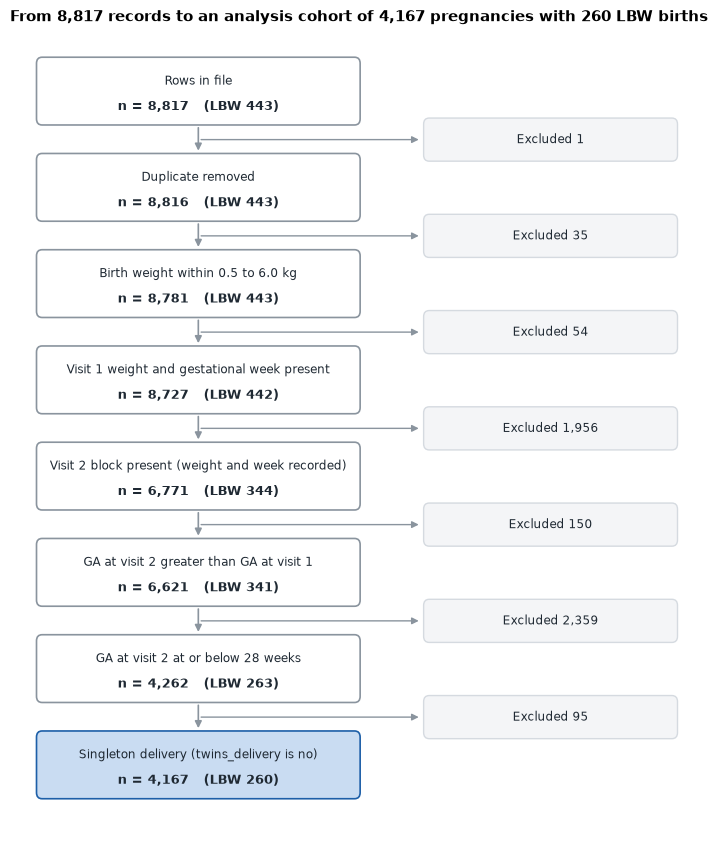

In [35]:
def draw_flow(ax, flow, title):
    ax.set_xlim(0, 10)
    ax.set_ylim(0.3, len(flow) * 1.25 + 0.8)
    ax.axis("off")
    top = len(flow) * 1.25
    for i, r in enumerate(flow.itertuples()):
        y = top - i * 1.25
        is_last = i == len(flow) - 1
        box_colour = PALE_BLUE if is_last else "white"
        ax.add_patch(FancyBboxPatch((0.4, y - 0.42), 4.6, 0.84, boxstyle="round,pad=0.02,rounding_size=0.08",
                                    facecolor=box_colour, edgecolor=BLUE if is_last else GREY, linewidth=1.2))
        label = r.rule if i == 0 else f"{r.rule}"
        ax.text(2.7, y + 0.13, label, ha="center", va="center", fontsize=8.5, color=INK, wrap=True)
        ax.text(2.7, y - 0.2, f"n = {r.n_after:,}   (LBW {r.lbw_after})", ha="center", va="center", fontsize=9, color=INK, weight="bold")
        if i > 0:
            ax.annotate("", xy=(2.7, y + 0.44), xytext=(2.7, y + 0.81),
                        arrowprops=dict(arrowstyle="-|>", color=GREY, linewidth=1.2))
            ax.annotate("", xy=(5.9, y + 0.62), xytext=(2.7, y + 0.62),
                        arrowprops=dict(arrowstyle="-|>", color=GREY, linewidth=1))
            ax.add_patch(FancyBboxPatch((5.95, y + 0.36), 3.6, 0.52, boxstyle="round,pad=0.02,rounding_size=0.08",
                                        facecolor="#f4f5f7", edgecolor=LIGHT_GREY))
            ax.text(7.75, y + 0.62, f"Excluded {r.n_dropped:,}", ha="center", va="center", fontsize=8.5, color=INK)
    ax.set_title(title, loc="left")


fig, ax = plt.subplots(figsize=(9, 10.5))
draw_flow(ax, cohort_flow, f"From 8,817 records to an analysis cohort of {cohort_n:,} pregnancies with {cohort_events} LBW births")
save_fig(fig, "fig01_cohort_flow")

Figure 1. Cohort flow. Each box shows the pregnancies remaining after a rule, with the number of LBW births in brackets; the grey box to the right shows how many the rule removed. The blue box is the analysis cohort.

In [36]:
in_32 = (~work[[flag for flag, _, _ in STEPS if flag != "excl_after_cutoff"]].any(axis=1)) & (ga2 <= CONFIG["ga_cutoff_sensitivity"])
work["in_sensitivity_32wk"] = in_32
work["in_no_parity_conflict"] = work["in_analysis_cohort"] & (work["qc_parity_conflict"] == 0)
cohorts = {
    "analysis_28wk": (int(work["in_analysis_cohort"].sum()), int(work.loc[work["in_analysis_cohort"], "lbw"].sum())),
    "sensitivity_32wk": (int(in_32.sum()), int(work.loc[in_32, "lbw"].sum())),
    "no_parity_conflict": (int(work["in_no_parity_conflict"].sum()), int(work.loc[work["in_no_parity_conflict"], "lbw"].sum())),
}
for name, (n, events) in cohorts.items():
    print(f"{name:<20} n = {n:,}, LBW = {events} ({events / n * 100:.2f}%)")
assert cohorts["sensitivity_32wk"] == (5392, 301)

COHORT = work["in_analysis_cohort"]
MANIFEST["cohort_flow"] = cohort_flow.to_dict(orient="records")
MANIFEST["cohort_flow_quoted_with_duplicate"] = quoted
MANIFEST["cohorts"] = {k: {"n": n, "lbw": e, "lbw_percent": round(e / n * 100, 2)} for k, (n, e) in cohorts.items()}

analysis_28wk        n = 4,167, LBW = 260 (6.24%)
sensitivity_32wk     n = 5,392, LBW = 301 (5.58%)
no_parity_conflict   n = 1,833, LBW = 98 (5.35%)


### Interpretation

Applying the rules in order takes the file from 8,817 records to an analysis cohort of 4,167 pregnancies with 260 LBW births (6.24 percent). The quoted counts in the brief are reproduced exactly when the duplicate is kept, and every corrected count is one lower, as explained in the note above. The two largest steps are losing women without a measured second visit (1,956 dropped, with almost the same LBW rate as those kept, 5.0 against 5.1 percent) and the 28 week cutoff (2,359 dropped, LBW 3.3 percent against 6.2 percent kept). The cutoff step raises the LBW rate because women whose second visit happens late are, by definition, still pregnant late and so less likely to deliver early. Age, number of pregnancies and HIV share hardly differ between kept and dropped women, so the cohort looks broadly like the full file apart from visit timing. Decision: the analysis cohort is fixed at 4,167 pregnancies; the 32 week cohort (5,392 pregnancies, 301 LBW) and the cohort without parity conflicts (1,833 pregnancies, 98 LBW) are used for sensitivity analyses.

## Section 9. Cleaning and plausibility bounds

Some recorded values are impossible: an age of 121, a height of 0 cm. For every bounded measurement we create two new columns and leave the original untouched:

* `clean_<field>` holds the value, or a missing value if it falls outside the plausible range in `CONFIG["bounds"]`.
* `flag_<field>_oob` is 1 when a recorded value was out of bounds, so the model can still learn if errors themselves carry information.

In [37]:
B = CONFIG["bounds"]
bp1, bp2 = bp_parsed_v1, bp_parsed_v2
BOUNDED = {
    # name: (numeric values, source column, rule key)
    "age": (raw["age"].astype(float), "age", "age"),
    "height_cm": (raw["height_cm"].astype(float), "height_cm", "height_cm"),
    "weight_booking": (booking_weight, "weight_kg", "weight"),
    "weight_v1": (raw["weight_kg_v1"].astype(float), "weight_kg_v1", "weight"),
    "weight_v2": (raw["weight_kg_v2"].astype(float), "weight_kg_v2", "weight"),
    "sbp_v1": (bp1["systolic"], "blood_pressure_v1", "systolic"),
    "sbp_v2": (bp2["systolic"], "blood_pressure_v2", "systolic"),
    "dbp_v1": (bp1["diastolic"], "blood_pressure_v1", "diastolic"),
    "dbp_v2": (bp2["diastolic"], "blood_pressure_v2", "diastolic"),
    "hb_v1": (to_num(raw["hemoglobin_check_result_v1"]), "hemoglobin_check_result_v1", "haemoglobin"),
    "hb_v2": (to_num(raw["hemoglobin_check_result_v2"]), "hemoglobin_check_result_v2", "haemoglobin"),
    "temp_v1": (to_num(raw["body_temperature_v1"]), "body_temperature_v1", "temperature"),
    "temp_v2": (to_num(raw["body_temperature_v2"]), "body_temperature_v2", "temperature"),
    "pulse_v1": (to_num(raw["pulse_rate_v1"]), "pulse_rate_v1", "pulse"),
    "pulse_v2": (to_num(raw["pulse_rate_v2"]), "pulse_rate_v2", "pulse"),
    "rr_v1": (to_num(raw["respiratory_rate_v1"]), "respiratory_rate_v1", "respiratory_rate"),
    "rr_v2": (to_num(raw["respiratory_rate_v2"]), "respiratory_rate_v2", "respiratory_rate"),
}


def apply_bound(name, values, rule):
    low, high = B[rule]
    out_of_bounds = values.notna() & ~values.between(low, high)
    work[f"clean_{name}"] = values.where(~out_of_bounds)
    work[f"flag_{name}_oob"] = out_of_bounds.astype(int)


for name, (values, source, rule) in BOUNDED.items():
    apply_bound(name, values, rule)

# Weekly weight change uses the cleaned weights and only rows where visit 2 comes after visit 1.
weeks_between = (ga2 - ga1).where(ga2 > ga1)
weekly_change = (work["clean_weight_v2"] - work["clean_weight_v1"]) / weeks_between
BOUNDED["wt_change_per_week"] = (weekly_change, "weight_kg_v1, weight_kg_v2, pregnant_week_number_v1, pregnant_week_number_v2", "weekly_weight_change")
apply_bound("wt_change_per_week", weekly_change, "weekly_weight_change")

bound_rows = []
for name, (values, source, rule) in BOUNDED.items():
    flag = work[f"flag_{name}_oob"].astype(bool)
    bound_rows.append({"field": name, "source": source, "rule": rule, "lower": B[rule][0], "upper": B[rule][1],
                       "non_missing_full": int(values.notna().sum()), "rows_out_of_bounds_full": int(flag.sum()),
                       "non_missing_cohort": int(values[COHORT].notna().sum()), "rows_out_of_bounds_cohort": int(flag[COHORT].sum())})
bounds_applied = save_table(pd.DataFrame(bound_rows), "tab09_bounds_applied")
assert raw.shape == (8817, 683) and sha256_of(DATA_PATH) == INPUT_SHA256
bounds_applied

,field,source,rule,lower,upper,non_missing_full,rows_out_of_bounds_full,non_missing_cohort,rows_out_of_bounds_cohort
0,age,age,age,12,55,8817,158,4167,80
1,height_cm,height_cm,height_cm,130,200,8817,34,4167,12
2,weight_booking,weight_kg,weight,30,150,8406,30,4112,14
3,weight_v1,weight_kg_v1,weight,30,150,8762,14,4167,8
4,weight_v2,weight_kg_v2,weight,30,150,6844,17,4167,10
5,sbp_v1,blood_pressure_v1,systolic,60,250,8657,7,4096,1
6,sbp_v2,blood_pressure_v2,systolic,60,250,6737,5,4084,3
7,dbp_v1,blood_pressure_v1,diastolic,30,150,8657,13,4096,1
8,dbp_v2,blood_pressure_v2,diastolic,30,150,6737,11,4084,6
9,hb_v1,hemoglobin_check_result_v1,haemoglobin,3,20,8125,20,3758,10


### Interpretation

The bounds remove very few values. The largest effects are on age (158 records outside 12 to 55 in the full file, 80 in the cohort), weekly weight change (96 in the full file, 57 in the cohort) and height (34 and 12). Blood pressure, pulse, temperature and haemoglobin each lose fewer than 25 values in the full file. Every change is reversible because the original columns are untouched, and every row touched carries a `flag_<field>_oob` indicator. Decision: the model uses only the `clean_` versions, and the flags are exported so the training notebook can test whether recording errors themselves carry signal.

## Section 10. Feature engineering

Here we turn the cleaned fields into the predictors the model will see. They come in three sets that answer the study question:

* Set A: everything known at the first visit (history, examination and tests at visit 1).
* Set B: set A plus the raw measurements from the second visit.
* Set C: set A plus the change between visit 1 and visit 2 (for example weight gain per week).

The comparison of B and C with A tells us whether a second visit adds predictive value. Every feature is listed with its source columns and definition in the feature dictionary (`tab10_feature_dictionary.csv`).

In [38]:
features = pd.DataFrame(index=pd.Index(work["SN"], name="SN"))
DICTIONARY = []


def add_feature(name, values, sources, definition, ftype, unit, group):
    """Add one feature to the frame and record it in the dictionary.

    group is "A" (baseline and visit 1), "B" (visit 2 measurement) or "C" (change).
    """
    features[name] = np.asarray(values, dtype=float)
    DICTIONARY.append({"feature": name, "source_columns": sources, "definition": definition,
                       "type": ftype, "unit": unit, "group": group})


def is_level(column, levels):
    """1 if the normalised text is one of levels, 0 if it is another value, NaN if missing."""
    text = norm_text(raw[column])
    return text.isin(levels).astype(float).where(text.notna())


def not_checked(column):
    return (norm_text(raw[column]).isin(["not_checked", "not checked"])).astype(float)


def mean_arterial(s, d):
    return (s + 2 * d) / 3


def bp_high(s, d):
    high = (s >= CONFIG["bp_high_systolic"]) | (d >= CONFIG["bp_high_diastolic"])
    return high.astype(float).where(s.notna() & d.notna())


malaria = {k: normalise_result(raw[f"malaria_rapid_test_result_v{k}"], CONFIG["result_mapping"]) for k in (1, 2)}

In [39]:
# Set A: baseline history
add_feature("age", work["clean_age"], "age", "Age in years, bounded 12 to 55", "continuous", "years", "A")
add_feature("gravidity", gravidity, "no_pregnancy", "Number of pregnancies including this one", "count", "pregnancies", "A")
add_feature("prior_deliveries", prior_deliveries, "number_of_prior_deliveries", "Number of previous deliveries", "count", "deliveries", "A")
add_feature("prior_live_births", raw["number_of_prior_pregnancies_with_live_births"], "number_of_prior_pregnancies_with_live_births", "Previous pregnancies ending in a live birth", "count", "pregnancies", "A")
add_feature("prior_stillbirths", raw["number_of_prior_pregnancies_with_stillbirths"], "number_of_prior_pregnancies_with_stillbirths", "Previous pregnancies ending in a stillbirth", "count", "pregnancies", "A")
add_feature("living_children", raw["number_of_living_children_and_birth_weight"], "number_of_living_children_and_birth_weight", "Number of living children", "count", "children", "A")
add_feature("prior_macrosomia", (raw["infant_weight_of_4kg_and_above"] > 0).astype(float), "infant_weight_of_4kg_and_above", "Any previous baby of 4 kg or more", "binary", "yes = 1", "A")
add_feature("prior_caesarean", yes_no(raw["prior_caesarean_delivery"]), "prior_caesarean_delivery", "Previous caesarean delivery", "binary", "yes = 1", "A")
add_feature("prior_miscarriage", yes_no(raw["miscarriages_or_abortions"]), "miscarriages_or_abortions", "Previous miscarriage or abortion (booking history field)", "binary", "yes = 1", "A")
bleeding_cols = ["bleeding_in_previous_pregnancies", "bleeding_in_previous_deliveries", "bleeding_in_previous_puerperium"]
add_feature("prior_bleeding_any", pd.concat([yes_no(raw[c]) for c in bleeding_cols], axis=1).max(axis=1), ", ".join(bleeding_cols), "Bleeding in any previous pregnancy, delivery or puerperium", "binary", "yes = 1", "A")
add_feature("prior_hypertension_pregnancy", yes_no(raw["presence_of_hypertension_in_previous_pregnancies"]), "presence_of_hypertension_in_previous_pregnancies", "Hypertension in a previous pregnancy", "binary", "yes = 1", "A")
add_feature("hiv_pos", hiv_any.astype(float), "hiv, hiv_test_result_v1", "HIV history yes or visit 1 test positive", "binary", "yes = 1", "A")
add_feature("twin_pregnancy_booking", yes_no(raw["twin_pregnancy"]), "twin_pregnancy", "Twin pregnancy recorded at booking", "binary", "yes = 1", "A")

# Set A: visit 1 examination
add_feature("height_cm", work["clean_height_cm"], "height_cm", "Height, bounded 130 to 200", "continuous", "cm", "A")
add_feature("weight_v1", work["clean_weight_v1"], "weight_kg_v1", "Weight at visit 1, bounded 30 to 150", "continuous", "kg", "A")
add_feature("bmi_v1", work["clean_weight_v1"] / (work["clean_height_cm"] / 100) ** 2, "weight_kg_v1, height_cm", "Body mass index at visit 1 (pregnant weight)", "continuous", "kg/m2", "A")
add_feature("ga_v1", ga1, "pregnant_week_number_v1", "Gestational week at visit 1", "continuous", "weeks", "A")
add_feature("sbp_v1", work["clean_sbp_v1"], "blood_pressure_v1", "Systolic BP at visit 1, bounded 60 to 250", "continuous", "mmHg", "A")
add_feature("dbp_v1", work["clean_dbp_v1"], "blood_pressure_v1", "Diastolic BP at visit 1, bounded 30 to 150", "continuous", "mmHg", "A")
add_feature("map_v1", mean_arterial(work["clean_sbp_v1"], work["clean_dbp_v1"]), "blood_pressure_v1", "Mean arterial pressure (systolic + 2 x diastolic) / 3", "continuous", "mmHg", "A")
add_feature("bp_high_v1", bp_high(work["clean_sbp_v1"], work["clean_dbp_v1"]), "blood_pressure_v1", "Systolic at or above 140 or diastolic at or above 90", "binary", "yes = 1", "A")
add_feature("pulse_v1", work["clean_pulse_v1"], "pulse_rate_v1", "Pulse at visit 1, bounded 40 to 180", "continuous", "beats/min", "A")
add_feature("temp_v1", work["clean_temp_v1"], "body_temperature_v1", "Temperature at visit 1, bounded 34 to 42", "continuous", "degrees C", "A")
add_feature("rr_v1", work["clean_rr_v1"], "respiratory_rate_v1", "Respiratory rate at visit 1, bounded 8 to 60", "continuous", "breaths/min", "A")
add_feature("hb_v1", work["clean_hb_v1"], "hemoglobin_check_result_v1", "Haemoglobin at visit 1, bounded 3 to 20", "continuous", "g/dL", "A")
add_feature("anaemia_v1", (work["clean_hb_v1"] < CONFIG["anaemia_hb"]).astype(float).where(work["clean_hb_v1"].notna()), "hemoglobin_check_result_v1", "Haemoglobin below 11 g/dL", "binary", "yes = 1", "A")
add_feature("severe_anaemia_v1", (work["clean_hb_v1"] < CONFIG["severe_anaemia_hb"]).astype(float).where(work["clean_hb_v1"].notna()), "hemoglobin_check_result_v1", "Haemoglobin below 7 g/dL", "binary", "yes = 1", "A")
add_feature("malaria_pos_v1", malaria[1].map({"positive": 1.0, "negative": 0.0}), "malaria_rapid_test_result_v1", "Malaria rapid test positive (other or missing results are NaN)", "binary", "yes = 1", "A")
add_feature("syphilis_pos_v1", is_level("syphilis_test_result_v1", ["positive"]), "syphilis_test_result_v1", "Syphilis test positive", "binary", "yes = 1", "A")
add_feature("urine_albumin_pos_v1", is_level("urine_albumin_check_result_v1", CONFIG["urine_albumin_positive"]), "urine_albumin_check_result_v1", "Urine protein positive", "binary", "yes = 1", "A")
add_feature("sfh_abnormal_v1", is_level("uterine_size_symphysis_fundal_height_v1", ["abnormal"]), "uterine_size_symphysis_fundal_height_v1", "Fundal height recorded as abnormal", "binary", "yes = 1", "A")
add_feature("fetal_heart_absent_v1", is_level("fetal_auscaltation_v1", ["not present"]), "fetal_auscaltation_v1", "Fetal heart not heard (expected before about 20 weeks)", "binary", "yes = 1", "A")
add_feature("palpation_abnormal_v1", is_level("abdominal_palpation_v1", CONFIG["palpation_abnormal"]), "abdominal_palpation_v1", "Breech or transverse lie on palpation", "binary", "yes = 1", "A")

# Set A: visit 1 social and preventive care
add_feature("social_support_absent_v1", is_level("social_support_v1", ["no"]), "social_support_v1", "No social support reported", "binary", "yes = 1", "A")
add_feature("ipv_v1", yes_no(raw["intimate_partner_violence_v1"]), "intimate_partner_violence_v1", "Intimate partner violence reported", "binary", "yes = 1", "A")
add_feature("gbv_v1", yes_no(raw["gbv_v1"]), "gbv_v1", "Gender based violence reported", "binary", "yes = 1", "A")
add_feature("substance_v1", pd.concat([yes_no(raw["smoking_v1"]), yes_no(raw["alcohol_and_drugs_abuse_v1"])], axis=1).max(axis=1), "smoking_v1, alcohol_and_drugs_abuse_v1", "Smoking or alcohol and drug use", "binary", "yes = 1", "A")
add_feature("ifa_v1", yes_no(raw["iron_and_folic_v1"]), "iron_and_folic_v1", "Iron and folic acid given", "binary", "yes = 1", "A")
add_feature("iptp_v1", yes_no(raw["give_intermittent_preventive_treatment_of_malaria_in_gravidity_v1"]), "give_intermittent_preventive_treatment_of_malaria_in_gravidity_v1", "Intermittent preventive malaria treatment given", "binary", "yes = 1", "A")
add_feature("llin_v1", yes_no(raw["provide_long_lasting_v1"]), "provide_long_lasting_v1", "Long lasting insecticidal net provided", "binary", "yes = 1", "A")
add_feature("tt_not_vaccinated_v1", is_level("tetanus_immunization_status_v1", ["not vaccinated"]), "tetanus_immunization_status_v1", "Never vaccinated against tetanus", "binary", "yes = 1", "A")
add_feature("problem_treated_v1", yes_no(raw["treat_any_problem_observed_v1"]), "treat_any_problem_observed_v1", "A problem was observed and treated at visit 1", "binary", "yes = 1", "A")

# Set A: not checked indicators for visit 1 vitals
for vital, column in [("bp", "blood_pressure_v1"), ("pulse", "pulse_rate_v1"), ("temp", "body_temperature_v1"), ("rr", "respiratory_rate_v1")]:
    add_feature(f"not_checked_{vital}_v1", not_checked(column), column, f"{vital} recorded as not checked at visit 1", "binary", "yes = 1", "A")
add_feature("not_checked_hb_v1", is_level("hemoglobin_check_v1", ["no"]).fillna(0), "hemoglobin_check_v1", "Haemoglobin not checked at visit 1", "binary", "yes = 1", "A")
print(f"Set A candidate features: {sum(d['group'] == 'A' for d in DICTIONARY)}")

Set A candidate features: 47


In [40]:
# Visit 2 measurements (candidates for set B)
add_feature("weight_v2", work["clean_weight_v2"], "weight_kg_v2", "Weight at visit 2, bounded 30 to 150", "continuous", "kg", "B")
add_feature("ga_v2", ga2, "pregnant_week_number_v2", "Gestational week at visit 2", "continuous", "weeks", "B")
add_feature("gap_weeks", (ga2 - ga1), "pregnant_week_number_v1, pregnant_week_number_v2", "Weeks between visit 1 and visit 2", "continuous", "weeks", "B")
add_feature("sbp_v2", work["clean_sbp_v2"], "blood_pressure_v2", "Systolic BP at visit 2", "continuous", "mmHg", "B")
add_feature("dbp_v2", work["clean_dbp_v2"], "blood_pressure_v2", "Diastolic BP at visit 2", "continuous", "mmHg", "B")
add_feature("map_v2", mean_arterial(work["clean_sbp_v2"], work["clean_dbp_v2"]), "blood_pressure_v2", "Mean arterial pressure at visit 2", "continuous", "mmHg", "B")
add_feature("bp_high_v2", bp_high(work["clean_sbp_v2"], work["clean_dbp_v2"]), "blood_pressure_v2", "BP at or above 140/90 at visit 2", "binary", "yes = 1", "B")
add_feature("pulse_v2", work["clean_pulse_v2"], "pulse_rate_v2", "Pulse at visit 2", "continuous", "beats/min", "B")
add_feature("temp_v2", work["clean_temp_v2"], "body_temperature_v2", "Temperature at visit 2", "continuous", "degrees C", "B")
add_feature("rr_v2", work["clean_rr_v2"], "respiratory_rate_v2", "Respiratory rate at visit 2", "continuous", "breaths/min", "B")
add_feature("hb_v2", work["clean_hb_v2"], "hemoglobin_check_result_v2", "Haemoglobin at visit 2", "continuous", "g/dL", "B")
add_feature("sfh_abnormal_v2", is_level("uterine_size_symphysis_fundal_height_v2", ["abnormal"]), "uterine_size_symphysis_fundal_height_v2", "Fundal height abnormal at visit 2", "binary", "yes = 1", "B")
add_feature("fetal_heart_absent_v2", is_level("fetal_auscaltation_v2", ["not present"]), "fetal_auscaltation_v2", "Fetal heart not heard at visit 2", "binary", "yes = 1", "B")
add_feature("palpation_abnormal_v2", is_level("abdominal_palpation_v2", CONFIG["palpation_abnormal"]), "abdominal_palpation_v2", "Breech or transverse lie at visit 2", "binary", "yes = 1", "B")
add_feature("urine_albumin_pos_v2", is_level("urine_albumin_check_result_v2", CONFIG["urine_albumin_positive"]), "urine_albumin_check_result_v2", "Urine protein positive at visit 2", "binary", "yes = 1", "B")
add_feature("malaria_pos_v2", malaria[2].map({"positive": 1.0, "negative": 0.0}), "malaria_rapid_test_result_v2", "Malaria rapid test positive at visit 2", "binary", "yes = 1", "B")
for vital, column in [("bp", "blood_pressure_v2"), ("pulse", "pulse_rate_v2"), ("temp", "body_temperature_v2"), ("rr", "respiratory_rate_v2")]:
    add_feature(f"not_checked_{vital}_v2", not_checked(column).where(raw["weight_kg_v2"].notna()), column, f"{vital} recorded as not checked at visit 2", "binary", "yes = 1", "B")

# Change between visits (candidates for set C)
add_feature("wt_change_per_week", work["clean_wt_change_per_week"], "weight_kg_v1, weight_kg_v2, pregnant_week_number_v1, pregnant_week_number_v2", "(weight v2 minus weight v1) / weeks between, bounded minus 2 to 3", "continuous", "kg/week", "C")
add_feature("sbp_change", features["sbp_v2"] - features["sbp_v1"], "blood_pressure_v1, blood_pressure_v2", "Systolic v2 minus v1", "continuous", "mmHg", "C")
add_feature("dbp_change", features["dbp_v2"] - features["dbp_v1"], "blood_pressure_v1, blood_pressure_v2", "Diastolic v2 minus v1", "continuous", "mmHg", "C")
add_feature("map_change", features["map_v2"] - features["map_v1"], "blood_pressure_v1, blood_pressure_v2", "Mean arterial pressure v2 minus v1", "continuous", "mmHg", "C")
add_feature("bp_new_high", ((features["bp_high_v1"] == 0) & (features["bp_high_v2"] == 1)).astype(float).where(features["bp_high_v1"].notna() & features["bp_high_v2"].notna()), "blood_pressure_v1, blood_pressure_v2", "Normal BP at visit 1 and 140/90 or above at visit 2", "binary", "yes = 1", "C")
add_feature("sfh_became_abnormal", ((features["sfh_abnormal_v1"] == 0) & (features["sfh_abnormal_v2"] == 1)).astype(float).where(features["sfh_abnormal_v1"].notna() & features["sfh_abnormal_v2"].notna()), "uterine_size_symphysis_fundal_height_v1, _v2", "Fundal height normal at visit 1 and abnormal at visit 2", "binary", "yes = 1", "C")
add_feature("hb_change", features["hb_v2"] - features["hb_v1"], "hemoglobin_check_result_v1, hemoglobin_check_result_v2", "Haemoglobin v2 minus v1 where both present", "continuous", "g/dL", "C")
add_feature("pulse_change", features["pulse_v2"] - features["pulse_v1"], "pulse_rate_v1, pulse_rate_v2", "Pulse v2 minus v1", "continuous", "beats/min", "C")
print(f"Total candidate features: {features.shape[1]}")

Total candidate features: 75


### Availability screen

A visit 2 measurement is only useful if clinics actually record it. A measurement enters set B or C only if it is usable (recorded and plausible) at both visits for at least 70 percent of the analysis cohort. Measurements that fail are left out of both sets so the model is not built on data that most clinics do not collect.

In [41]:
fc = features[COHORT.to_numpy()]
SCREEN = {
    # family: (visit 1 column, visit 2 column, set B features, set C features)
    "weight": ("weight_v1", "weight_v2", ["weight_v2"], ["wt_change_per_week"]),
    "gestational_week": ("ga_v1", "ga_v2", ["ga_v2", "gap_weeks"], []),
    "blood_pressure": ("sbp_v1", "sbp_v2", ["sbp_v2", "dbp_v2", "map_v2", "bp_high_v2", "not_checked_bp_v2"], ["sbp_change", "dbp_change", "map_change", "bp_new_high"]),
    "pulse": ("pulse_v1", "pulse_v2", ["pulse_v2", "not_checked_pulse_v2"], ["pulse_change"]),
    "temperature": ("temp_v1", "temp_v2", ["temp_v2", "not_checked_temp_v2"], []),
    "respiratory_rate": ("rr_v1", "rr_v2", ["rr_v2", "not_checked_rr_v2"], []),
    "haemoglobin": ("hb_v1", "hb_v2", ["hb_v2"], ["hb_change"]),
    "fundal_height": ("sfh_abnormal_v1", "sfh_abnormal_v2", ["sfh_abnormal_v2"], ["sfh_became_abnormal"]),
    "fetal_heart": ("fetal_heart_absent_v1", "fetal_heart_absent_v2", ["fetal_heart_absent_v2"], []),
    "palpation": ("palpation_abnormal_v1", "palpation_abnormal_v2", ["palpation_abnormal_v2"], []),
    "urine_albumin": ("urine_albumin_pos_v1", "urine_albumin_pos_v2", ["urine_albumin_pos_v2"], []),
    "malaria": ("malaria_pos_v1", "malaria_pos_v2", ["malaria_pos_v2"], []),
}
screen_rows = []
for family, (c1, c2, b_feats, c_feats) in SCREEN.items():
    share_v2 = fc[c2].notna().mean()
    share_both = (fc[c1].notna() & fc[c2].notna()).mean()
    screen_rows.append({"measurement": family, "visit1_feature": c1, "visit2_feature": c2,
                        "available_v2_percent": round(share_v2 * 100, 1), "available_both_percent": round(share_both * 100, 1),
                        "result": "pass" if share_both >= CONFIG["availability_threshold"] else "fail",
                        "set_B_features": ", ".join(b_feats), "set_C_features": ", ".join(c_feats)})
availability_screen = save_table(pd.DataFrame(screen_rows), "tab11_availability_screen")
passed = availability_screen.set_index("measurement")["result"].eq("pass")
for family in ["weight", "blood_pressure", "pulse", "gestational_week"]:
    assert passed[family], family
assert not passed["haemoglobin"]
availability_screen

,measurement,visit1_feature,visit2_feature,available_v2_percent,available_both_percent,result,set_B_features,set_C_features
0,weight,weight_v1,weight_v2,99.8,99.6,pass,weight_v2,wt_change_per_week
1,gestational_week,ga_v1,ga_v2,100.0,100.0,pass,"ga_v2, gap_weeks",
2,blood_pressure,sbp_v1,sbp_v2,97.9,96.6,pass,"sbp_v2, dbp_v2, map_v2, bp_high_v2, not_checke...","sbp_change, dbp_change, map_change, bp_new_high"
3,pulse,pulse_v1,pulse_v2,80.0,78.6,pass,"pulse_v2, not_checked_pulse_v2",pulse_change
4,temperature,temp_v1,temp_v2,57.7,57.2,fail,"temp_v2, not_checked_temp_v2",
5,respiratory_rate,rr_v1,rr_v2,58.2,57.8,fail,"rr_v2, not_checked_rr_v2",
6,haemoglobin,hb_v1,hb_v2,37.9,34.4,fail,hb_v2,hb_change
7,fundal_height,sfh_abnormal_v1,sfh_abnormal_v2,100.0,100.0,pass,sfh_abnormal_v2,sfh_became_abnormal
8,fetal_heart,fetal_heart_absent_v1,fetal_heart_absent_v2,100.0,100.0,pass,fetal_heart_absent_v2,
9,palpation,palpation_abnormal_v1,palpation_abnormal_v2,100.0,100.0,pass,palpation_abnormal_v2,


In [42]:
SET_A = [d["feature"] for d in DICTIONARY if d["group"] == "A"]
B_EXTRA = [f for fam, (_, _, b, _) in SCREEN.items() if passed[fam] for f in b]
C_EXTRA = [f for fam, (_, _, _, c) in SCREEN.items() if passed[fam] for f in c]
SET_B = SET_A + B_EXTRA
SET_C = SET_A + C_EXTRA
ALL_MODEL_FEATURES = list(dict.fromkeys(SET_A + B_EXTRA + C_EXTRA))
SCREENED_OUT = [f for f in features.columns if f not in ALL_MODEL_FEATURES]

missing_pct = (fc.isna().mean() * 100).round(1)
feature_dictionary = pd.DataFrame(DICTIONARY)
feature_dictionary["set_A"] = feature_dictionary["feature"].isin(SET_A).map({True: "yes", False: ""})
feature_dictionary["set_B"] = feature_dictionary["feature"].isin(SET_B).map({True: "yes", False: ""})
feature_dictionary["set_C"] = feature_dictionary["feature"].isin(SET_C).map({True: "yes", False: ""})
feature_dictionary["screened_out"] = feature_dictionary["feature"].isin(SCREENED_OUT).map({True: "yes", False: ""})
feature_dictionary["percent_missing_cohort"] = feature_dictionary["feature"].map(missing_pct)
save_table(feature_dictionary, "tab10_feature_dictionary")

# No field on the never use list may appear as a feature or feed one.
never_use = set(CONFIG["never_use"])
assert not never_use & set(features.columns)
used_sources = {s.strip() for d in DICTIONARY if d["feature"] in ALL_MODEL_FEATURES for s in d["source_columns"].split(",")}
used_sources = {s for s in used_sources if s in raw.columns}
assert not used_sources & never_use, used_sources & never_use

print(f"Set A: {len(SET_A)} features; set B: {len(SET_B)} (adds {len(B_EXTRA)}); set C: {len(SET_C)} (adds {len(C_EXTRA)})")
print("Screened out:", SCREENED_OUT)
MANIFEST["feature_sets"] = {"A": SET_A, "B": SET_B, "C": SET_C, "screened_out": SCREENED_OUT}

Set A: 47 features; set B: 60 (adds 13); set C: 54 (adds 7)
Screened out: ['temp_v2', 'rr_v2', 'hb_v2', 'urine_albumin_pos_v2', 'malaria_pos_v2', 'not_checked_temp_v2', 'not_checked_rr_v2', 'hb_change']


### Interpretation

Set A holds 47 features known at the first visit, set B adds 13 visit 2 features (60 in total) and set C adds 7 change features (54 in total). The availability screen passes weight (99.6 percent usable at both visits), gestational week (100 percent), blood pressure (96.6 percent), pulse (78.6 percent) and the three examination findings. It fails temperature (57 percent), respiratory rate (58 percent), haemoglobin (34 percent at both visits; 38 percent at visit 2 alone, as quoted), malaria (19 percent) and urine protein (9 percent), so `hb_change` and those visit 2 values are left out of sets B and C. Two features need caution when reading results: `prior_macrosomia` is positive for 56 percent of women, far too many for babies of 4 kg or more, and `fetal_heart_absent_v1` mostly reflects early pregnancy, when the heart cannot yet be heard. Decision: the feature sets are fixed as listed in Table 10, and the code confirms that no never use column feeds any feature.

## Section 11. Descriptive tables

Table 1 describes the analysis cohort, split by whether the baby was LBW. Differences are shown as standardised mean differences (SMD), which put every feature on the same scale; values below 0.1 are usually considered negligible and values above 0.2 are worth noticing. We do not show p values, because with this many features some would look significant by chance.

In [43]:
y = work.loc[COHORT, "lbw"].to_numpy()
fc = features[COHORT.to_numpy()]
BINARY = set(feature_dictionary.loc[feature_dictionary["type"] == "binary", "feature"])


def smd(values, outcome, binary):
    a, b = values[outcome == 1], values[outcome == 0]
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    if binary:
        pa, pb = a.mean(), b.mean()
        pooled = np.sqrt((pa * (1 - pa) + pb * (1 - pb)) / 2)
        return (pa - pb) / pooled if pooled > 0 else 0.0
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0


def describe(values, binary):
    v = values[~np.isnan(values)]
    if len(v) == 0:
        return "no data"
    if binary:
        return f"{int(v.sum())} ({v.mean() * 100:.1f}%)"
    q1, q2, q3 = np.percentile(v, [25, 50, 75])
    return f"{q2:.1f} [{q1:.1f}, {q3:.1f}]"


table1_rows = [{"feature": "n", "set": "", "summary_type": "", "non_lbw": f"{(y == 0).sum():,}", "lbw": f"{(y == 1).sum():,}",
                "percent_missing": "", "smd": ""}]
for f in list(dict.fromkeys(SET_A + B_EXTRA)):
    values = fc[f].to_numpy()
    binary = f in BINARY
    table1_rows.append({"feature": f, "set": "A" if f in SET_A else "B", "summary_type": "count (%)" if binary else "median [IQR]",
                        "non_lbw": describe(values[y == 0], binary), "lbw": describe(values[y == 1], binary),
                        "percent_missing": round(np.isnan(values).mean() * 100, 1), "smd": round(smd(values, y, binary), 3)})
table1 = save_table(pd.DataFrame(table1_rows), "tab12_table1_by_lbw")
print("Features with |SMD| of 0.2 or more:")
print(table1[pd.to_numeric(table1["smd"], errors="coerce").abs() >= 0.2][["feature", "non_lbw", "lbw", "smd"]].to_string(index=False))
table1

Features with |SMD| of 0.2 or more:
              feature           non_lbw               lbw    smd
     prior_macrosomia      2188 (56.0%)       171 (65.8%)  0.201
    prior_miscarriage        123 (3.1%)         25 (9.6%)  0.267
            weight_v1 56.0 [51.0, 63.0] 54.0 [50.0, 60.0] -0.248
             pulse_v1 76.0 [72.0, 86.0] 79.0 [72.0, 89.0]  0.202
            weight_v2 58.0 [53.0, 65.0] 56.0 [51.4, 61.0] -0.266
             pulse_v2 76.0 [72.0, 86.0] 80.0 [72.0, 88.0]  0.211
fetal_heart_absent_v2      1464 (37.5%)       125 (48.1%)  0.216


,feature,set,summary_type,non_lbw,lbw,percent_missing,smd
0,n,,,"3,907",260,,
1,age,A,median [IQR],"25.0 [21.0, 30.0]","23.0 [20.0, 31.0]",1.9,-0.117
2,gravidity,A,median [IQR],"2.0 [1.0, 3.0]","2.0 [1.0, 3.0]",0.0,-0.134
3,prior_deliveries,A,median [IQR],"2.0 [1.0, 3.0]","2.0 [1.0, 3.0]",0.0,0.001
4,prior_live_births,A,median [IQR],"2.0 [1.0, 3.0]","2.0 [1.0, 3.0]",0.0,0.037
...,...,...,...,...,...,...,...
56,pulse_v2,B,median [IQR],"76.0 [72.0, 86.0]","80.0 [72.0, 88.0]",20.0,0.211
57,not_checked_pulse_v2,B,count (%),784 (20.1%),47 (18.1%),0.0,-0.051
58,sfh_abnormal_v2,B,count (%),14 (0.4%),4 (1.5%),0.0,0.122
59,fetal_heart_absent_v2,B,count (%),1464 (37.5%),125 (48.1%),0.0,0.216


In [44]:
visit_rows = []
for k in range(1, 9):
    present = block_present[k]
    measures = {
        "weight_kg": raw[f"weight_kg_v{k}"].astype(float),
        "systolic_mmHg": parse_bp(raw[f"blood_pressure_v{k}"])["systolic"],
        "diastolic_mmHg": parse_bp(raw[f"blood_pressure_v{k}"])["diastolic"],
        "pulse_per_min": to_num(raw[f"pulse_rate_v{k}"]),
        "temperature_C": to_num(raw[f"body_temperature_v{k}"]),
        "haemoglobin_g_dL": to_num(raw[f"hemoglobin_check_result_v{k}"]),
        "gestational_week": raw[f"pregnant_week_number_v{k}"].astype(float),
    }
    for name, values in measures.items():
        v = values[present]
        q = v.quantile([0.25, 0.5, 0.75])
        visit_rows.append({"visit": k, "measurement": name, "visits_held": int(present.sum()), "n": int(v.notna().sum()),
                           "median": q[0.5], "q1": q[0.25], "q3": q[0.75],
                           "percent_missing": round(v.isna().mean() * 100, 1)})
visit_measurements = save_table(pd.DataFrame(visit_rows), "tab13_visit_measurements")
visit_measurements.pivot(index="measurement", columns="visit", values="median")

visit,1,2,3,4,5,6,7,8
measurement,,,,,,,,
diastolic_mmHg,68.0,68.0,68.0,70.0,70.0,70.0,70.0,70.0
gestational_week,21.0,26.0,30.0,32.0,35.0,36.0,37.0,38.0
haemoglobin_g_dL,11.7,11.0,11.0,11.7,11.9,12.0,12.0,11.4
pulse_per_min,76.0,76.0,76.0,76.0,76.0,77.0,78.0,76.0
systolic_mmHg,112.0,112.0,111.0,110.0,110.0,110.0,110.0,115.0
temperature_C,36.9,36.9,36.9,36.9,37.0,37.0,37.0,36.8
weight_kg,57.7,59.0,60.0,62.0,63.0,64.0,64.4,66.0


In Table 13, percent missing is calculated among women who attended that visit, so it shows how often clinics skip a measurement rather than how many women never came back.

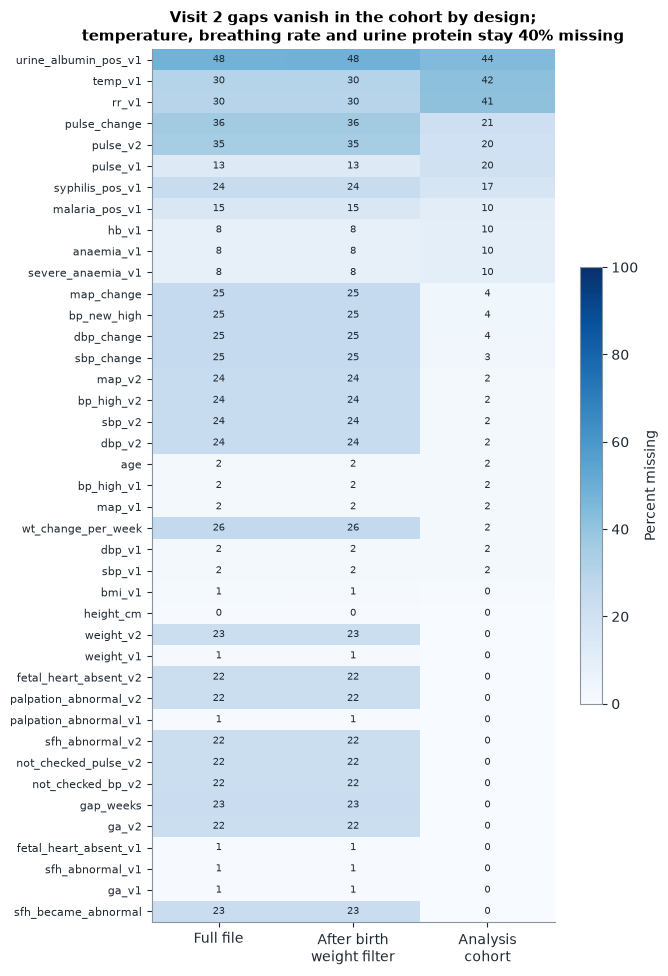

26 model features have no missing values at any stage and are not shown.


In [45]:
bw_ok = ~work["excl_duplicate"] & ~work["excl_birth_weight"]
stages = {"Full file": pd.Series(True, index=work.index), "After birth weight filter": bw_ok, "Analysis cohort": COHORT}
missingness = pd.DataFrame({stage: features[mask.to_numpy()][ALL_MODEL_FEATURES].isna().mean() * 100
                            for stage, mask in stages.items()}).round(1)
missingness.index.name = "feature"
save_table(missingness, "tab14_missingness", index=True)

shown = missingness[missingness.max(axis=1) > 0].sort_values("Analysis cohort", ascending=False)
fig, ax = plt.subplots(figsize=(6.5, 0.24 * len(shown) + 1.5))
image = ax.imshow(shown.to_numpy(), cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(shown.shape[1]), ["Full file", "After birth\nweight filter", "Analysis\ncohort"])
ax.set_yticks(range(len(shown)), shown.index, fontsize=8)
ax.grid(False)
for i in range(shown.shape[0]):
    for j in range(shown.shape[1]):
        value = shown.iat[i, j]
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=7, color="white" if value > 55 else INK)
fig.colorbar(image, ax=ax, label="Percent missing", shrink=0.5)
ax.set_title("Visit 2 gaps vanish in the cohort by design;\ntemperature, breathing rate and urine protein stay 40% missing")
save_fig(fig, "fig07_missingness_heatmap")
print(f"{(missingness.max(axis=1) == 0).sum()} model features have no missing values at any stage and are not shown.")

Figure 7. Percent missing for each model feature with any missing values, at three stages of the cohort flow. Darker cells mean more missing data.

### Interpretation

Table 1 shows that LBW and non LBW pregnancies look very similar on almost every feature. Only seven features reach a standardised mean difference of 0.2: mothers of LBW babies weighed about 2 kg less at both visits (median 54 against 56 kg at visit 1), had a slightly higher pulse (79 against 76 beats per minute), more often reported a previous miscarriage (9.6 against 3.1 percent) and more often had no fetal heart heard at visit 2. Table 13 shows that visit measurements change only slowly over pregnancy (weight rises from about 58 to 66 kg across eight visits) and that haemoglobin, temperature and respiratory rate are often skipped. The missingness heatmap shows that visit 2 gaps disappear in the cohort, as the inclusion rules require, but temperature and respiratory rate become more often missing (30 percent in the full file, 42 percent in the cohort) and urine protein stays missing for about 44 percent. Decision: no single feature separates the groups well, so any model will rely on many small effects combined.

## Section 12. Association screen

Before building any model we look at each feature on its own. The AUROC (area under the receiver operating characteristic curve) answers a simple question: if we pick one LBW baby and one normal weight baby at random, how often does this feature rank the LBW baby as higher risk? A value of 0.5 is a coin toss and 1.0 is perfect. We report every AUROC at or above 0.5 and state the direction (for example "lower is riskier"), with a 95 percent interval from 500 bootstrap resamples.

In [46]:
rng = np.random.default_rng(RANDOM_STATE)


def fast_auc(scores, outcome):
    ranks = stats.rankdata(scores)
    n1 = outcome.sum()
    n0 = len(outcome) - n1
    return (ranks[outcome == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def lbw_by_level(values, outcome, binary):
    if binary or len(np.unique(values)) <= 4:
        levels = sorted(np.unique(values))
        return "; ".join(f"{lvl:g}: {outcome[values == lvl].mean() * 100:.1f}%" for lvl in levels)
    quartile = pd.qcut(values, 4, labels=False, duplicates="drop")
    return "; ".join(f"Q{int(q) + 1}: {outcome[quartile == q].mean() * 100:.1f}%" for q in np.unique(quartile))


screen = []
for f in ALL_MODEL_FEATURES:
    values = fc[f].to_numpy()
    keep = ~np.isnan(values)
    v, o = values[keep], y[keep]
    if o.sum() < 5 or len(np.unique(v)) < 2:
        continue
    auc = fast_auc(v, o)
    flip = auc < 0.5
    boot = np.empty(CONFIG["bootstrap_samples"])
    for b in range(CONFIG["bootstrap_samples"]):
        idx = rng.integers(0, len(v), len(v))
        ob = o[idx]
        boot[b] = fast_auc(v[idx], ob) if 0 < ob.sum() < len(ob) else np.nan
    if flip:
        auc, boot = 1 - auc, 1 - boot
    sets = "".join(s for s, members in (("A", SET_A), ("B", SET_B), ("C", SET_C)) if f in members)
    screen.append({"feature": f, "sets": sets, "n": int(keep.sum()), "lbw_n": int(o.sum()), "auroc": round(auc, 3),
                   "ci_low": round(np.nanpercentile(boot, 2.5), 3), "ci_high": round(np.nanpercentile(boot, 97.5), 3),
                   "direction": "lower is riskier" if flip else "higher is riskier",
                   "lbw_rate_by_level": lbw_by_level(v, o, f in BINARY), "smd": round(smd(values, y, f in BINARY), 3)})
univariate = save_table(pd.DataFrame(screen).sort_values("auroc", ascending=False), "tab15_univariate_screen")
univariate.head(15)

,feature,sets,n,lbw_n,auroc,ci_low,ci_high,direction,lbw_rate_by_level,smd
47,weight_v2,B,4157,260,0.577,0.541,0.611,lower is riskier,Q1: 8.3%; Q2: 5.7%; Q3: 6.9%; Q4: 3.9%,-0.266
14,weight_v1,ABC,4159,260,0.574,0.538,0.612,lower is riskier,Q1: 8.0%; Q2: 6.5%; Q3: 6.6%; Q4: 3.8%,-0.248
21,pulse_v1,ABC,3352,212,0.563,0.522,0.603,higher is riskier,Q1: 4.9%; Q2: 5.9%; Q3: 6.3%; Q4: 8.9%,0.202
55,pulse_v2,B,3332,212,0.563,0.527,0.601,higher is riskier,Q1: 5.3%; Q2: 4.4%; Q3: 7.7%; Q4: 7.9%,0.211
58,fetal_heart_absent_v2,B,4167,260,0.553,0.523,0.583,higher is riskier,0: 5.2%; 1: 7.9%,0.216
6,prior_macrosomia,ABC,4167,260,0.549,0.518,0.579,higher is riskier,0: 4.9%; 1: 7.2%,0.201
0,age,ABC,4087,254,0.549,0.512,0.589,lower is riskier,Q1: 8.1%; Q2: 5.5%; Q3: 3.8%; Q4: 6.5%,-0.117
48,ga_v2,B,4167,260,0.546,0.507,0.585,lower is riskier,Q1: 7.1%; Q2: 6.9%; Q3: 5.2%; Q4: 4.7%,-0.169
1,gravidity,ABC,4167,260,0.539,0.506,0.570,lower is riskier,Q1: 6.8%; Q2: 5.7%; Q3: 4.7%,-0.134
22,temp_v1,ABC,2428,138,0.536,0.491,0.586,higher is riskier,Q1: 4.9%; Q2: 5.8%; Q3: 9.3%,0.104


In [47]:
top = univariate.iloc[0]
print(f"Strongest single feature: {top.feature} (AUROC {top.auroc}, 95% CI {top.ci_low} to {top.ci_high}, {top.direction})")
near_null = univariate.set_index("feature").loc[["hb_v1", "wt_change_per_week", "malaria_pos_v1", "ipv_v1"], ["auroc", "ci_low", "ci_high"]]
print("\nFeatures expected to be near 0.50:")
print(near_null.to_string())
assert univariate["auroc"].max() <= 0.60
assert top.feature in ("weight_v1", "weight_v2") and abs(top.auroc - 0.57) <= 0.015
assert (near_null["auroc"] < 0.55).all()
MANIFEST["univariate_top10"] = univariate.head(10)[["feature", "auroc", "ci_low", "ci_high", "direction"]].to_dict(orient="records")

Strongest single feature: weight_v2 (AUROC 0.577, 95% CI 0.541 to 0.611, lower is riskier)

Features expected to be near 0.50:
                    auroc  ci_low  ci_high
feature                                   
hb_v1               0.516   0.474    0.553
wt_change_per_week  0.508   0.474    0.541
malaria_pos_v1      0.501   0.496    0.508
ipv_v1              0.501   0.494    0.509


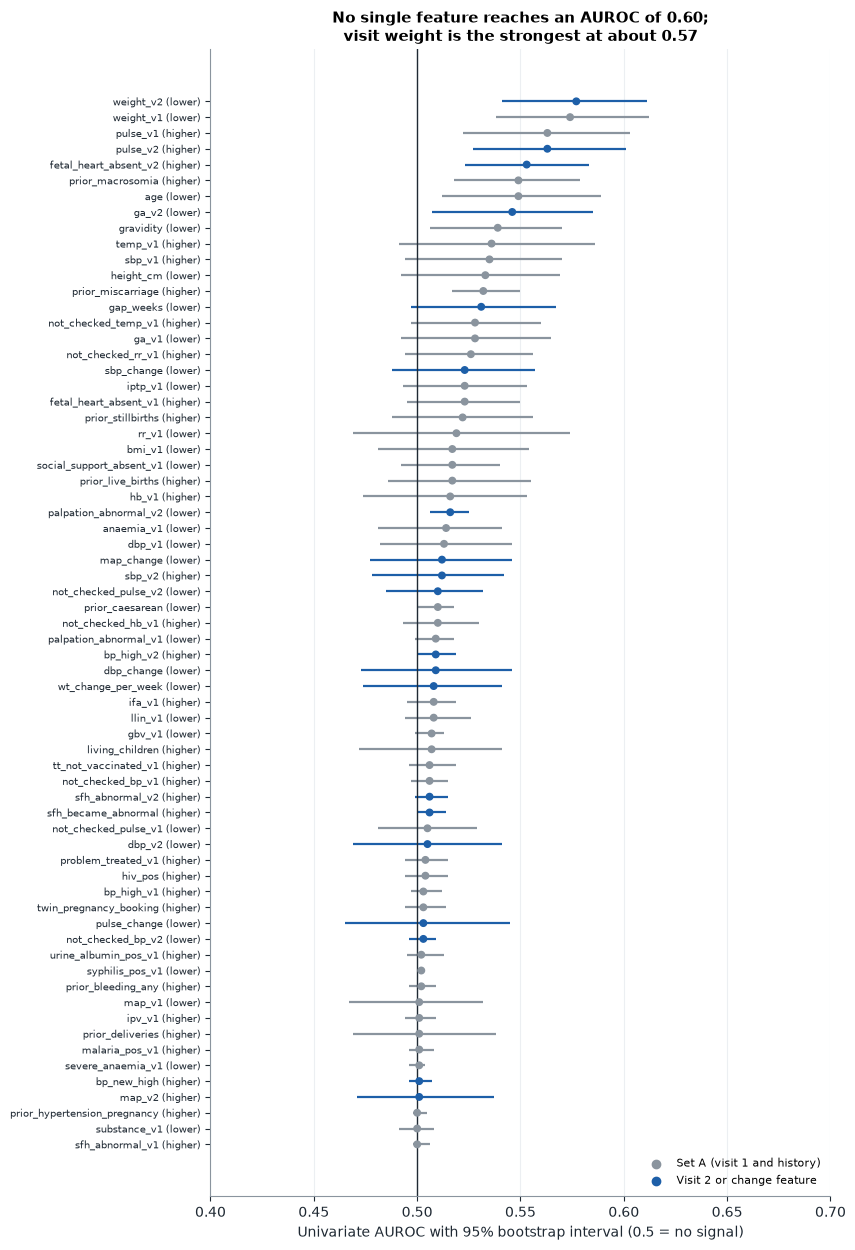

In [48]:
plot_data = univariate.sort_values("auroc")
fig, ax = plt.subplots(figsize=(8, 0.2 * len(plot_data) + 1.5))
ypos = np.arange(len(plot_data))
colour = [GREY if "A" in s else BLUE for s in plot_data["sets"]]
ax.hlines(ypos, plot_data["ci_low"], plot_data["ci_high"], color=colour, linewidth=1.6)
ax.scatter(plot_data["auroc"], ypos, color=colour, s=22, zorder=3)
ax.axvline(0.5, color=INK, linewidth=1)
ax.set_yticks(ypos, [f"{f} ({'lower' if d.startswith('lower') else 'higher'})" for f, d in zip(plot_data["feature"], plot_data["direction"])], fontsize=7.5)
ax.set_xlabel("Univariate AUROC with 95% bootstrap interval (0.5 = no signal)")
ax.set_xlim(0.4, 0.7)
ax.grid(axis="y", visible=False)
ax.set_title("No single feature reaches an AUROC of 0.60;\nvisit weight is the strongest at about 0.57")
ax.scatter([], [], color=GREY, label="Set A (visit 1 and history)")
ax.scatter([], [], color=BLUE, label="Visit 2 or change feature")
ax.legend(loc="lower right", fontsize=8)
save_fig(fig, "fig08_univariate_auroc")

Figure 8. Univariate AUROC for every model feature in the analysis cohort, sorted from strongest to weakest. The label in brackets gives the direction of risk. Blue features need the second visit.

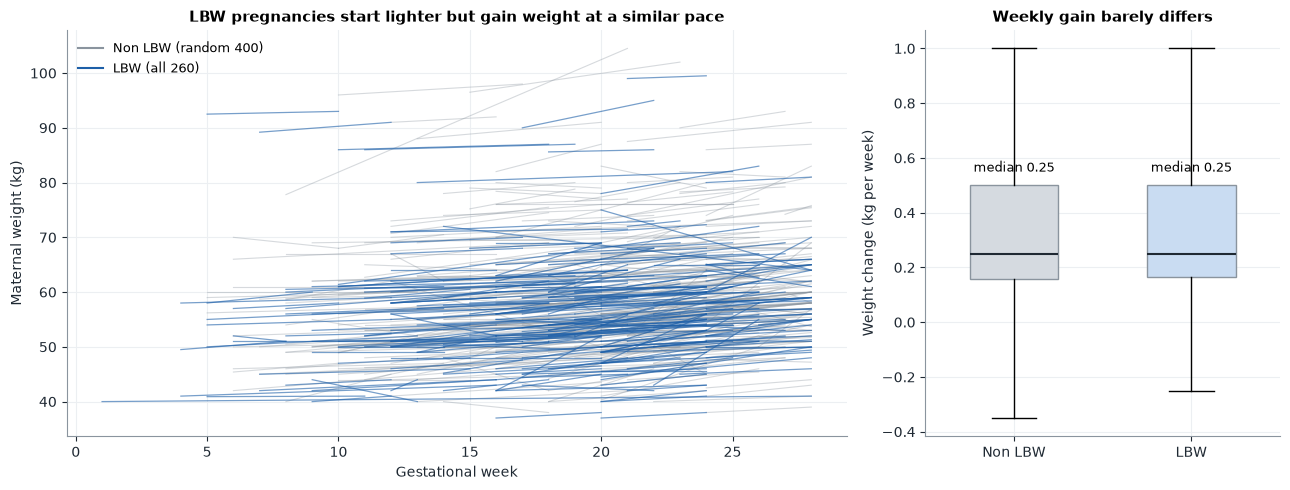

In [49]:
traj = fc[["ga_v1", "weight_v1", "ga_v2", "weight_v2", "wt_change_per_week"]].copy()
traj["lbw"] = y
traj = traj.dropna(subset=["ga_v1", "weight_v1", "ga_v2", "weight_v2"])
sample_non = traj[traj["lbw"] == 0].sample(CONFIG["trajectory_sample_non_lbw"], random_state=RANDOM_STATE)
lbw_rows = traj[traj["lbw"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.2, 1]})
for r in sample_non.itertuples():
    axes[0].plot([r.ga_v1, r.ga_v2], [r.weight_v1, r.weight_v2], color=GREY, alpha=0.35, linewidth=0.8)
for r in lbw_rows.itertuples():
    axes[0].plot([r.ga_v1, r.ga_v2], [r.weight_v1, r.weight_v2], color=BLUE, alpha=0.6, linewidth=0.9)
axes[0].plot([], [], color=GREY, label=f"Non LBW (random {len(sample_non)})")
axes[0].plot([], [], color=BLUE, label=f"LBW (all {len(lbw_rows)})")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_xlabel("Gestational week")
axes[0].set_ylabel("Maternal weight (kg)")
axes[0].set_title("LBW pregnancies start lighter but gain weight at a similar pace")

change = [traj.loc[traj["lbw"] == g, "wt_change_per_week"].dropna() for g in (0, 1)]
parts = axes[1].boxplot(change, tick_labels=["Non LBW", "LBW"], widths=0.5, patch_artist=True, showfliers=False,
                        medianprops=dict(color=INK, linewidth=1.5))
for patch, colour_ in zip(parts["boxes"], [LIGHT_GREY, PALE_BLUE]):
    patch.set_facecolor(colour_)
    patch.set_edgecolor(GREY)
for i, values in enumerate(change, start=1):
    axes[1].text(i, values.quantile(0.75) + 0.05, f"median {values.median():.2f}", ha="center", fontsize=9)
axes[1].set_ylabel("Weight change (kg per week)")
axes[1].set_title("Weekly gain barely differs")
fig.tight_layout()
save_fig(fig, "fig09_weight_trajectories")

Figure 9. Left: each line joins a woman's weight at visit 1 to her weight at visit 2, plotted against gestational week; all LBW pregnancies are drawn in blue on top of a random sample of 400 non LBW pregnancies in grey. Right: weekly weight change by LBW status (boxes show the median and interquartile range; outliers hidden).

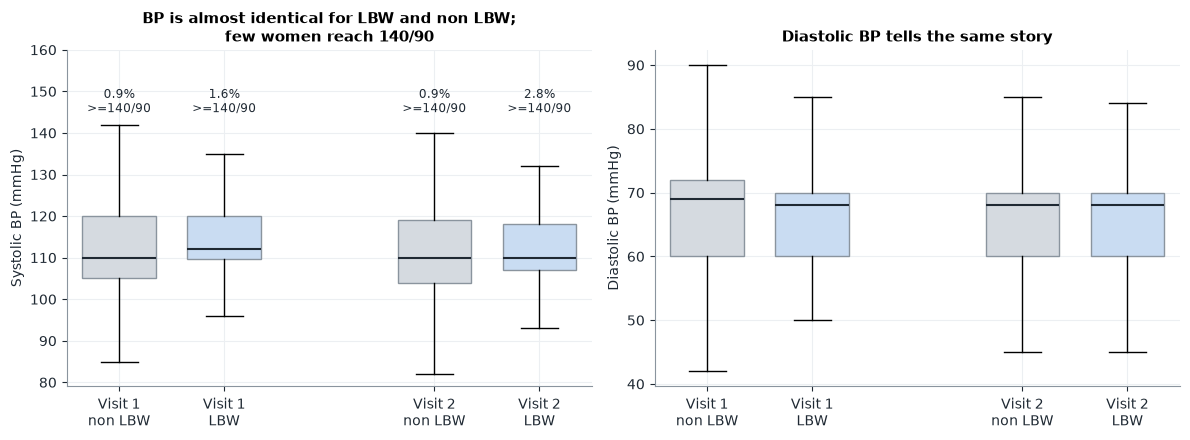

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, measure, label in [(axes[0], "sbp", "Systolic BP (mmHg)"), (axes[1], "dbp", "Diastolic BP (mmHg)")]:
    data, positions, colours_ = [], [], []
    for visit_i, visit in enumerate((1, 2)):
        for group in (0, 1):
            data.append(fc.loc[y == group, f"{measure}_v{visit}"].dropna())
            positions.append(visit_i * 3 + group)
            colours_.append(PALE_BLUE if group else LIGHT_GREY)
    parts = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False,
                       medianprops=dict(color=INK, linewidth=1.5))
    for patch, colour_ in zip(parts["boxes"], colours_):
        patch.set_facecolor(colour_)
        patch.set_edgecolor(GREY)
    ax.set_xticks([0, 1, 3, 4], ["Visit 1\nnon LBW", "Visit 1\nLBW", "Visit 2\nnon LBW", "Visit 2\nLBW"])
    ax.set_ylabel(label)
    top_y = max(d.quantile(0.75) for d in data) + 25
    if measure == "sbp":
        for visit_i, visit in enumerate((1, 2)):
            for group in (0, 1):
                share = fc.loc[y == group, f"bp_high_v{visit}"].mean() * 100
                ax.text(visit_i * 3 + group, top_y, f"{share:.1f}%\n>=140/90", ha="center", fontsize=8.5, color=INK)
        ax.set_ylim(top=top_y + 15)
axes[0].set_title("BP is almost identical for LBW and non LBW;\nfew women reach 140/90")
axes[1].set_title("Diastolic BP tells the same story")
fig.tight_layout()
save_fig(fig, "fig10_bp_by_visit")

Figure 10. Systolic (left) and diastolic (right) blood pressure at visits 1 and 2 by LBW status, analysis cohort. Boxes show the median and interquartile range. Percentages above the left panel are the share of women with a reading at or above 140/90 at that visit.

### Interpretation

The signal is weak. The strongest single feature is maternal weight at visit 2 with an AUROC of 0.577 (95 percent interval 0.541 to 0.611), followed by visit 1 weight (0.574) and pulse (0.563); nothing reaches 0.60. Haemoglobin (0.516), weekly weight gain (0.508), malaria (0.501) and intimate partner violence (0.501) are close to a coin toss. The trajectories show that LBW pregnancies start a little lighter but gain weight at the same pace (median 0.25 kg per week in both groups), and readings at or above 140/90 are too rare to help (2.8 against 0.9 percent at visit 2). For the study claim this means we should not expect a clinically strong screening tool from routine visit data; the honest question is whether a second visit adds a measurable amount to the first, and the answer is likely to be small.

## Section 13. Multivariable structure and missingness mechanism

Here we check three things that matter for modelling: which features carry the same information (high correlation and variance inflation), whether the measurements separate LBW from non LBW when looked at together (principal components), and whether the missing laboratory results are missing at random or for reasons tied to the outcome or to time.

Pairs with |Spearman| above 0.85:
 feature_1  feature_2  spearman
 weight_v1  weight_v2     0.929
    dbp_v1     map_v1     0.911
    dbp_v2     map_v2     0.911
dbp_change map_change     0.899


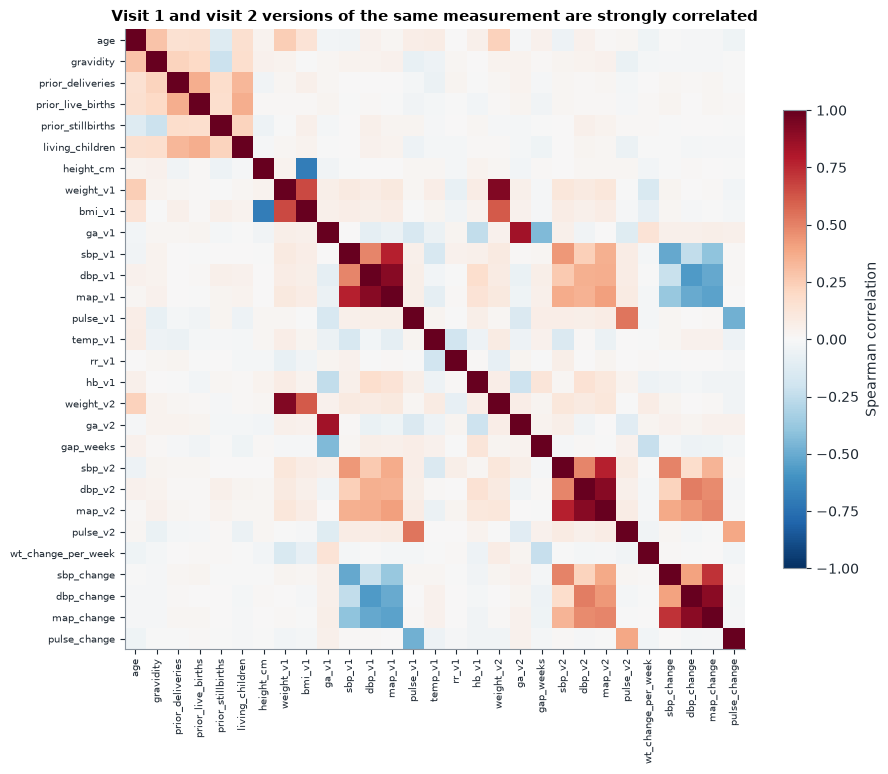

In [51]:
numeric_features = [f for f in ALL_MODEL_FEATURES if f not in BINARY]
corr = fc[numeric_features].corr(method="spearman")
pairs = []
for i, a in enumerate(numeric_features):
    for b in numeric_features[i + 1:]:
        if abs(corr.loc[a, b]) > CONFIG["correlation_flag"]:
            pairs.append({"feature_1": a, "feature_2": b, "spearman": round(corr.loc[a, b], 3)})
high_corr = pd.DataFrame(pairs).sort_values("spearman", key=abs, ascending=False)
print(f"Pairs with |Spearman| above {CONFIG['correlation_flag']}:")
print(high_corr.to_string(index=False))
assert {"weight_v1", "weight_v2"} in [{r.feature_1, r.feature_2} for r in high_corr.itertuples()]

fig, ax = plt.subplots(figsize=(10, 8.5))
image = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(corr)), corr.index, fontsize=7.5)
ax.grid(False)
fig.colorbar(image, ax=ax, label="Spearman correlation", shrink=0.7)
ax.set_title("Visit 1 and visit 2 versions of the same measurement are strongly correlated")
save_fig(fig, "fig11_correlation")
MANIFEST["high_correlation_pairs"] = high_corr.to_dict(orient="records")

Figure 11. Spearman correlation between the numeric model features in the analysis cohort. Dark red is strong positive correlation and dark blue strong negative; the diverging scale is the one exception to the single colour rule, because the sign matters.

In [52]:
def vif_table(columns_):
    X = fc[columns_].copy()
    X = X.loc[:, X.std() > 0]
    X = (X.fillna(X.median()) - X.median()) / X.std()
    X = X.assign(intercept=1.0)
    values = X.to_numpy()
    out = [{"feature": c, "vif": variance_inflation_factor(values, i)} for i, c in enumerate(X.columns) if c != "intercept"]
    return pd.DataFrame(out).sort_values("vif", ascending=False)


# map_v1, map_v2 and gap_weeks are exact linear combinations of other set B features
# (MAP = (systolic + 2 x diastolic) / 3; gap = ga_v2 minus ga_v1), so their VIF is infinite.
# We leave them out of the VIF calculation and report that fact instead.
EXACT_COMBINATIONS = {"map_v1": "sbp_v1, dbp_v1", "map_v2": "sbp_v2, dbp_v2", "gap_weeks": "ga_v1, ga_v2"}
vif_b = vif_table([f for f in SET_B if f not in EXACT_COMBINATIONS])
print("Exact linear combinations left out of the VIF:", EXACT_COMBINATIONS)
print("\nVariance inflation factors for the rest of set B (above 5 shown):")
print(vif_b[vif_b["vif"] > 5].round(1).to_string(index=False))
MANIFEST["vif_set_B"] = {"exact_combinations": EXACT_COMBINATIONS,
                         "above_5": vif_b[vif_b["vif"] > 5].round(2).to_dict(orient="records")}

Exact linear combinations left out of the VIF: {'map_v1': 'sbp_v1, dbp_v1', 'map_v2': 'sbp_v2, dbp_v2', 'gap_weeks': 'ga_v1, ga_v2'}

Variance inflation factors for the rest of set B (above 5 shown):
             feature  vif
              bmi_v1 42.3
   not_checked_rr_v1 31.9
 not_checked_temp_v1 31.9
           weight_v1 30.7
           height_cm 21.6
              ipv_v1 10.8
        substance_v1 10.8
           weight_v2  9.1
not_checked_pulse_v1  8.9
not_checked_pulse_v2  8.6


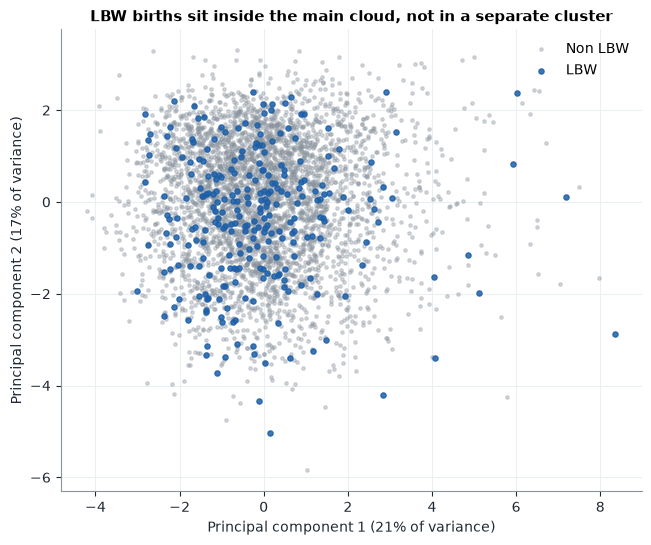

            PC1   PC2
weight_v1  0.45  0.24
weight_v2  0.45  0.24
sbp_v1     0.37 -0.12
sbp_v2     0.38 -0.07
dbp_v1     0.37 -0.17
dbp_v2     0.36 -0.11
pulse_v1   0.08 -0.20
pulse_v2   0.08 -0.18
ga_v1     -0.03  0.61
ga_v2     -0.02  0.61
height_cm  0.02 -0.02
age        0.17  0.10


In [53]:
vitals = ["weight_v1", "weight_v2", "sbp_v1", "sbp_v2", "dbp_v1", "dbp_v2", "pulse_v1", "pulse_v2", "ga_v1", "ga_v2", "height_cm", "age"]
Xv = fc[vitals]
Xv = (Xv.fillna(Xv.median()) - Xv.median()) / Xv.std()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(Xv)
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(components[y == 0, 0], components[y == 0, 1], s=6, color=GREY, alpha=0.35, label="Non LBW")
ax.scatter(components[y == 1, 0], components[y == 1, 1], s=14, color=BLUE, alpha=0.85, label="LBW")
ax.set_xlabel(f"Principal component 1 ({explained[0]:.0f}% of variance)")
ax.set_ylabel(f"Principal component 2 ({explained[1]:.0f}% of variance)")
ax.set_title("LBW births sit inside the main cloud, not in a separate cluster")
ax.legend(loc="upper right")
save_fig(fig, "fig12_pca")
loadings = pd.DataFrame(pca.components_.T, index=vitals, columns=["PC1", "PC2"]).round(2)
print(loadings.to_string())

Figure 12. First two principal components of twelve standardised vitals and body measurements (missing values set to the median). LBW births in blue are drawn on top of non LBW births in grey.

In [54]:
mechanism_rows = []
cohort_sn_block = work.loc[COHORT, "sn_block"].to_numpy()
cohort_age = work.loc[COHORT, "clean_age"].to_numpy()
for f in ["hb_v1", "urine_albumin_pos_v1", "syphilis_pos_v1"]:
    has_value = fc[f].notna().to_numpy()
    for label_, mask in [("value present", has_value), ("value missing", ~has_value)]:
        lo, hi = wilson(y[mask].sum(), mask.sum())
        mechanism_rows.append({"feature": f, "group": label_, "n": int(mask.sum()),
                               "lbw_percent": round(y[mask].mean() * 100, 2), "lbw_ci_low": round(lo * 100, 2), "lbw_ci_high": round(hi * 100, 2),
                               "median_age": float(np.nanmedian(cohort_age[mask])), "mean_sn_decile": round(cohort_sn_block[mask].mean(), 2)})
    by_decile = pd.Series(has_value).groupby(cohort_sn_block).mean() * 100
    print(f"{f}: percent present by SN decile ->", by_decile.round(0).astype(int).tolist())
missingness_mechanism = save_table(pd.DataFrame(mechanism_rows), "tab16_missingness_mechanism")
missingness_mechanism

hb_v1: percent present by SN decile -> [82, 87, 91, 94, 90, 93, 92, 91, 90, 92]
urine_albumin_pos_v1: percent present by SN decile -> [64, 54, 53, 45, 53, 56, 57, 59, 54, 62]
syphilis_pos_v1: percent present by SN decile -> [77, 82, 75, 84, 87, 87, 86, 81, 88, 89]


,feature,group,n,lbw_percent,lbw_ci_low,lbw_ci_high,median_age,mean_sn_decile
0,hb_v1,value present,3748,6.14,5.41,6.95,25.0,5.18
1,hb_v1,value missing,419,7.16,5.06,10.04,24.0,4.49
2,urine_albumin_pos_v1,value present,2326,6.96,6.00,8.07,25.0,5.15
3,urine_albumin_pos_v1,value missing,1841,5.32,4.39,6.44,25.0,5.07
4,syphilis_pos_v1,value present,3466,6.43,5.66,7.30,24.0,5.23
5,syphilis_pos_v1,value missing,701,5.28,3.85,7.19,25.0,4.55


### Interpretation

Four pairs of features are correlated above 0.85: weight at visit 1 and visit 2 (0.93), diastolic pressure and mean arterial pressure at each visit (0.91), and their changes (0.90). Mean arterial pressure and the gap in weeks are exact combinations of other features, so a linear model cannot separate their effects; among the rest, body mass index overlaps with weight and height (VIF 42, 31 and 22), temperature and respiratory rate are almost always skipped together (VIF 32 for both "not checked" indicators), and the identical violence and substance answers found in Section 7 show up again (VIF 11). The two principal components describe body size with blood pressure (first) and gestational week (second), and LBW births sit inside the main cloud rather than forming their own group. For missing laboratory values, LBW rates with and without a value differ by only about one percentage point with overlapping intervals, while haemoglobin testing rises from 82 percent in the first SN decile to about 90 percent later. Decision: missingness looks driven by time and clinic practice rather than by the outcome, so median imputation with missing indicators is acceptable, and the training notebook should keep only one of each highly correlated or duplicated pair in linear models.

## Section 14. Sample size and pre specified plan

How many predictors can 260 LBW births support before a model starts memorising noise? We use the criteria of Riley and colleagues (BMJ 2020) for a binary outcome. They ask for enough data that (1) the model needs only mild shrinkage (expected shrinkage factor 0.9), (2) the apparent and adjusted Nagelkerke R squared differ by no more than 0.05, and (3) the overall risk is estimated within plus or minus 0.05. We assume a modest anticipated Cox Snell R squared of 15 percent of its maximum, which is generous given the weak univariate signal.

In [55]:
def riley_binary(n, events, shrinkage, r2_fraction, optimism, margin):
    """Riley et al. (2020) minimum sample size criteria for a binary outcome.

    Returns the outcome proportion, the maximum and anticipated Cox Snell R squared, the
    sample size needed per candidate parameter under criteria 1 and 2, and the sample
    size needed for criterion 3 (precise overall risk).
    """
    phi = events / n
    max_r2 = 1 - np.exp(2 * (phi * np.log(phi) + (1 - phi) * np.log(1 - phi)))
    r2 = r2_fraction * max_r2
    per_param_1 = 1 / ((shrinkage - 1) * np.log(1 - r2 / shrinkage))
    s_vh = r2 / (r2 + optimism * max_r2)
    per_param_2 = 1 / ((s_vh - 1) * np.log(1 - r2 / s_vh))
    n_criterion_3 = (1.96 / margin) ** 2 * phi * (1 - phi)
    return {"phi": phi, "max_r2_cs": max_r2, "r2_cs": r2, "shrinkage_criterion_2": s_vh,
            "n_per_parameter_1": per_param_1, "n_per_parameter_2": per_param_2, "n_criterion_3": n_criterion_3}


R = CONFIG["riley"]
riley = riley_binary(cohort_n, cohort_events, R["shrinkage"], R["r2_fraction_of_max"], R["nagelkerke_optimism"], R["intercept_margin"])
per_param = max(riley["n_per_parameter_1"], riley["n_per_parameter_2"])
max_parameters = int(np.floor(cohort_n / per_param))
print(f"Outcome proportion {riley['phi']:.4f}; max Cox Snell R2 {riley['max_r2_cs']:.3f}; anticipated R2 {riley['r2_cs']:.4f}")
print(f"Rows needed per parameter: criterion 1 {riley['n_per_parameter_1']:.1f}, criterion 2 {riley['n_per_parameter_2']:.1f}")
print(f"Rows needed for criterion 3 (precise intercept): {riley['n_criterion_3']:.0f} (we have {cohort_n:,})")
print(f"Maximum candidate parameters supported by {cohort_n:,} rows and {cohort_events} events: {max_parameters}")

riley_rows = []
for p in R["candidate_parameters"]:
    n_needed = max(np.ceil(p * per_param), np.ceil(riley["n_criterion_3"]))
    riley_rows.append({"parameters": p, "rows_needed": int(n_needed), "events_needed": int(np.ceil(n_needed * riley["phi"])),
                       "events_per_parameter": round(cohort_events / p, 1), "adequate": "yes" if n_needed <= cohort_n else "no"})
riley_table = pd.DataFrame(riley_rows)
print(riley_table.to_string(index=False))
MANIFEST["sample_size"] = {"max_parameters": max_parameters, **{k: round(float(v), 5) for k, v in riley.items()},
                           "by_parameters": riley_table.to_dict(orient="records")}

Outcome proportion 0.0624; max Cox Snell R2 0.373; anticipated R2 0.0560
Rows needed per parameter: criterion 1 155.7, criterion 2 51.6
Rows needed for criterion 3 (precise intercept): 90 (we have 4,167)
Maximum candidate parameters supported by 4,167 rows and 260 events: 26
 parameters  rows_needed  events_needed  events_per_parameter adequate
         15         2337            146                  17.3      yes
         25         3894            243                  10.4      yes
         40         6230            389                   6.5       no


### Pre specified analysis plan

This plan is written before any model is trained and fixes the comparisons in advance, so the results cannot steer the questions.

1. Primary comparison. Set B (visit 1 plus visit 2 measurements) against set A (visit 1 only).
2. Secondary comparison. Set C (visit 1 plus change between visits) against set A.
3. Cohort. Visit 2 at or before 28 weeks. Sensitivity analyses repeat everything with a 32 week cutoff and in the cohort without parity conflicts.
4. Validation design. Repeated nested stratified cross validation. Because there is no facility or mother identifier, blocks of consecutive SN (deciles, exported as `sn_block`) act as the grouping proxy. The last 20 percent of SN is sealed as a temporal confirmation set and is only opened once, after the model is fixed.
5. No class weighting. Probabilities must stay calibrated to the true LBW rate of about 6 percent.
6. Metrics. AUROC; AUPRC; calibration slope and intercept; Brier score; decision curve net benefit at risk thresholds from 5 to 20 percent; paired bootstrap difference in AUROC between sets; likelihood ratio test for the nested logistic models (A inside B, A inside C).
7. Minimum difference of interest. An AUROC gain of 0.02 for B or C over A is the smallest difference we would call meaningful. It is fixed here, before results are seen.
8. Expected finding. Based on Sections 12 and 15, we expect an AUROC of about 0.59 for set A and between 0.59 and 0.61 for sets B and C, so the gain from a second visit is likely close to or below 0.02 and smaller than its uncertainty. A clear and honest null result, that two routine visits do not meaningfully improve LBW prediction in this setting, is a valid and useful outcome of the study.

### Interpretation

With 4,167 pregnancies and 260 LBW births, the Riley criteria allow at most 26 candidate parameters; the binding requirement is criterion 1 (about 156 rows per parameter to keep shrinkage at 0.9). Fifteen parameters (17.3 events per parameter) and 25 parameters (10.4) are supportable, but 40 (6.5) are not. Set A alone already has 47 features and set B has 60, which is more than the data can support without help. Decision: the training notebook must use penalised models and should either reduce the candidate list (for example by dropping exact combinations and duplicates) or accept and report stronger shrinkage. The analysis plan above is fixed now, before any study results are seen.

## Section 15. Baseline signal check (not the study experiment)

This is a quick sanity check, not the study result. We fit two simple models on each feature set with plain 5 fold stratified cross validation:

* Penalised logistic regression: missing values filled with the median, features standardised, L2 penalty.
* A gradient boosted tree model (`HistGradientBoostingClassifier`) with shallow trees (depth 3), learning rate 0.05 and 200 iterations. It handles missing values itself.

A model that always predicts the overall LBW rate (the dummy) is the reference: its AUROC is 0.5 by definition.

In [56]:
def logistic_model():
    # LogisticRegression uses an L2 penalty by default.
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(C=CONFIG["logistic_C"], max_iter=5000))


def boosted_model():
    return HistGradientBoostingClassifier(**CONFIG["hgb_params"], random_state=RANDOM_STATE)


MODELS = {"dummy (prevalence)": lambda: DummyClassifier(strategy="prior"),
          "logistic L2": logistic_model, "gradient boosting": boosted_model}
FEATURE_SETS = {"A": SET_A, "B": SET_B, "C": SET_C}
folds = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=RANDOM_STATE)
scoring = {"auroc": "roc_auc", "auprc": "average_precision", "brier": "neg_brier_score"}

cv_rows = []
for set_name, cols_ in FEATURE_SETS.items():
    X = fc[cols_].to_numpy()
    for model_name, factory in MODELS.items():
        if model_name.startswith("dummy") and set_name != "A":
            continue
        result = cross_validate(factory(), X, y, cv=folds, scoring=scoring)
        cv_rows.append({"feature_set": set_name if not model_name.startswith("dummy") else "none", "model": model_name,
                        "n_features": len(cols_) if not model_name.startswith("dummy") else 0,
                        "auroc": result["test_auroc"].mean(), "auroc_sd": result["test_auroc"].std(),
                        "auprc": result["test_auprc"].mean(), "auprc_sd": result["test_auprc"].std(),
                        "brier": -result["test_brier"].mean(), "brier_sd": result["test_brier"].std()})
baseline_cv = pd.DataFrame(cv_rows).round(4)
print(f"5 fold stratified cross validation, n = {len(y):,}, LBW = {y.sum()} ({y.mean() * 100:.2f}%)")
baseline_cv

5 fold stratified cross validation, n = 4,167, LBW = 260 (6.24%)


,feature_set,model,n_features,auroc,auroc_sd,auprc,auprc_sd,brier,brier_sd
0,none,dummy (prevalence),0,0.5000,0.0000,0.0624,0.0000,0.0585,0.0000
1,A,logistic L2,47,0.5894,0.0389,0.1169,0.0326,0.0583,0.0013
2,A,gradient boosting,47,0.6035,0.0134,0.1187,0.0197,0.0583,0.0009
3,B,logistic L2,60,0.6074,0.0310,0.1337,0.0406,0.0579,0.0014
4,B,gradient boosting,60,0.6135,0.0256,0.1471,0.0270,0.0574,0.0011
5,C,logistic L2,54,0.5881,0.0325,0.1193,0.0399,0.0584,0.0014
6,C,gradient boosting,54,0.6216,0.0201,0.1274,0.0189,0.0579,0.0005


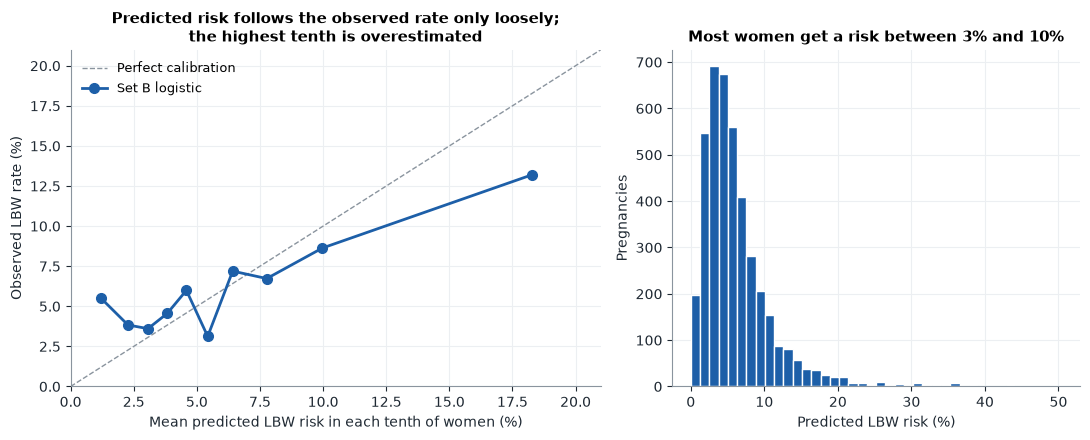

In [57]:
logit_auc = baseline_cv[baseline_cv["model"] == "logistic L2"].set_index("feature_set")["auroc"]
assert abs(logit_auc["A"] - 0.58) <= 0.02 and abs(logit_auc["B"] - 0.59) <= 0.02 and abs(logit_auc["C"] - 0.59) <= 0.02
assert baseline_cv["auroc"].max() < 0.65

proba_b = cross_val_predict(logistic_model(), fc[SET_B].to_numpy(), y, cv=folds, method="predict_proba")[:, 1]
observed, predicted = calibration_curve(y, proba_b, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})
lim = max(predicted.max(), observed.max()) * 1.15
axes[0].plot([0, lim * 100], [0, lim * 100], color=GREY, linestyle="--", linewidth=1, label="Perfect calibration")
axes[0].plot(predicted * 100, observed * 100, color=BLUE, marker="o", linewidth=2, markersize=7, label="Set B logistic")
axes[0].set_xlim(0, lim * 100)
axes[0].set_ylim(0, lim * 100)
axes[0].set_xlabel("Mean predicted LBW risk in each tenth of women (%)")
axes[0].set_ylabel("Observed LBW rate (%)")
axes[0].set_title("Predicted risk follows the observed rate only loosely;\nthe highest tenth is overestimated")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].hist(proba_b * 100, bins=40, color=BLUE, edgecolor="white")
axes[1].set_xlabel("Predicted LBW risk (%)")
axes[1].set_ylabel("Pregnancies")
axes[1].set_title("Most women get a risk between 3% and 10%")
fig.tight_layout()
save_fig(fig, "fig13_calibration_baseline")

Figure 13. Left: calibration of the set B logistic model using out of fold predictions, grouped into ten equal sized bins; points on the dashed line are perfectly calibrated. Right: distribution of the predicted risks.

In [58]:
order = np.argsort(work.loc[COHORT, "SN"].to_numpy())
n_train = int(round(len(order) * (1 - CONFIG["temporal_test_fraction"])))
train_idx, test_idx = order[:n_train], order[n_train:]
temporal_rows = []
for set_name, cols_ in FEATURE_SETS.items():
    X = fc[cols_].to_numpy()
    for model_name, factory in list(MODELS.items())[1:]:
        model = factory().fit(X[train_idx], y[train_idx])
        p = model.predict_proba(X[test_idx])[:, 1]
        temporal_rows.append({"feature_set": set_name, "model": model_name, "auroc": roc_auc_score(y[test_idx], p),
                              "auprc": average_precision_score(y[test_idx], p), "brier": brier_score_loss(y[test_idx], p)})
temporal = pd.DataFrame(temporal_rows).round(4)
comparison = temporal.merge(baseline_cv[["feature_set", "model", "auroc", "auroc_sd"]], on=["feature_set", "model"], suffixes=("_temporal", "_cv"))
comparison["difference"] = (comparison["auroc_temporal"] - comparison["auroc_cv"]).round(3)
print(f"Temporal split: train first {n_train:,} by SN ({y[train_idx].sum()} LBW), test last {len(test_idx):,} ({y[test_idx].sum()} LBW)")
comparison

Temporal split: train first 3,334 by SN (201 LBW), test last 833 (59 LBW)


,feature_set,model,auroc_temporal,auprc,brier,auroc_cv,auroc_sd,difference
0,A,logistic L2,0.5552,0.0982,0.0669,0.5894,0.0389,-0.034
1,A,gradient boosting,0.5543,0.0976,0.0673,0.6035,0.0134,-0.049
2,B,logistic L2,0.5697,0.1071,0.0667,0.6074,0.0310,-0.038
3,B,gradient boosting,0.5807,0.0939,0.0671,0.6135,0.0256,-0.033
4,C,logistic L2,0.5554,0.1005,0.0668,0.5881,0.0325,-0.033
5,C,gradient boosting,0.5645,0.0949,0.0673,0.6216,0.0201,-0.057


In [59]:
MANIFEST["baseline"] = {
    "cross_validation": baseline_cv.to_dict(orient="records"),
    "temporal_split": temporal.to_dict(orient="records"),
    "temporal_train_n": int(n_train), "temporal_test_n": int(len(test_idx)),
    "temporal_test_lbw": int(y[test_idx].sum()),
}

### Interpretation

This is a sanity check only, not the study result. With plain 5 fold cross validation the penalised logistic model reaches an AUROC of 0.589 for set A, 0.607 for set B and 0.588 for set C, and the boosted trees reach 0.604, 0.614 and 0.622; fold to fold variation (standard deviation 0.01 to 0.04) is as large as the differences between sets. AUPRC roughly doubles the 6.2 percent baseline, but the Brier score improves only slightly on the dummy (0.058 against 0.059), and calibration is loose, with the highest tenth of predictions overestimated. On the temporal split (first 80 percent of SN for training, last 20 percent for testing) every model loses 0.03 to 0.06 AUROC, so performance does not carry forward well over time. The study results will come from the nested, repeated design with SN blocks and the sealed temporal set in the next notebook.

## Section 16. Export and manifest

We write the analysis cohort and the two sensitivity cohorts as model ready files, then write `manifest.json` with every count, bound and decision made in this notebook. Finally we hash the raw file again to prove it was not changed.

In [60]:
flag_columns = [c for c in work.columns if c.startswith("flag_") and c.endswith("_oob")]
exclusion_flags = [flag for flag, _, _ in STEPS]
not_checked_cols = [c for c in features.columns if c.startswith("not_checked_")]
feature_export = list(dict.fromkeys(ALL_MODEL_FEATURES + not_checked_cols))


def export_frame(mask):
    left = work.loc[mask, ["SN", "lbw", "birth_weight_kg", "sn_block", "qc_parity_conflict", "in_analysis_cohort",
                           "in_sensitivity_32wk", "in_no_parity_conflict"] + exclusion_flags + flag_columns].reset_index(drop=True)
    right = features[mask.to_numpy()][feature_export].reset_index(drop=True)
    out = pd.concat([left, right], axis=1)
    out[exclusion_flags + ["in_analysis_cohort", "in_sensitivity_32wk", "in_no_parity_conflict"]] = \
        out[exclusion_flags + ["in_analysis_cohort", "in_sensitivity_32wk", "in_no_parity_conflict"]].astype(bool)
    return out


exports = {"cohort_analysis": COHORT, "cohort_sensitivity_32wk": work["in_sensitivity_32wk"], "cohort_no_parity_conflict": work["in_no_parity_conflict"]}
for name, mask in exports.items():
    frame = export_frame(mask)
    assert not set(frame.columns) & never_use
    frame.to_parquet(OUT_DIR / f"{name}.parquet", index=False)
    if name == "cohort_analysis":
        frame.to_csv(OUT_DIR / f"{name}.csv", index=False)
    print(f"{name:<28} {frame.shape[0]:>5,} rows, {frame.shape[1]} columns, LBW {int(frame['lbw'].sum())}")

check = pd.read_parquet(OUT_DIR / "cohort_analysis.parquet")
assert len(check) == cohort_n and int(check["lbw"].sum()) == cohort_events and check["SN"].is_unique

cohort_analysis              4,167 rows, 102 columns, LBW 260
cohort_sensitivity_32wk      5,392 rows, 102 columns, LBW 301
cohort_no_parity_conflict    1,833 rows, 102 columns, LBW 98


In [61]:
def to_json_safe(value):
    if isinstance(value, dict):
        return {str(k): to_json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [to_json_safe(v) for v in (sorted(value) if isinstance(value, set) else value)]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return None if np.isnan(value) else round(float(value), 6)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


table1_summary = {
    "n": cohort_n, "lbw": cohort_events, "lbw_percent": round(cohort_events / cohort_n * 100, 2),
    "largest_abs_smd": table1.assign(abs_smd=pd.to_numeric(table1["smd"], errors="coerce").abs())
                              .nlargest(5, "abs_smd")[["feature", "non_lbw", "lbw", "smd"]].to_dict(orient="records"),
}
manifest = {
    "notebook": "01_cohort_manifesto_and_eda.ipynb",
    "input_file": str(DATA_PATH), "input_sha256": INPUT_SHA256, "input_bytes": INPUT_BYTES, "input_shape": list(raw.shape),
    "run_timestamp_utc": RUN_TIMESTAMP, "library_versions": LIBRARY_VERSIONS,
    "config": printable(CONFIG),
    "block_sizes": block_sizes.to_dict(),
    "consistency_checks": consistency_table.to_dict(orient="records"),
    "bounds_applied": bounds_applied.to_dict(orient="records"),
    "never_use": CONFIG["never_use"],
    "never_use_reasons": excluded_fields["reason"].value_counts().to_dict(),
    "availability_screen": availability_screen.to_dict(orient="records"),
    "table1_summary": table1_summary,
    "baseline_auroc": {f"{r.model} / set {r.feature_set}": r.auroc for r in baseline_cv.itertuples()},
    **MANIFEST,
}
with open(OUT_DIR / "manifest.json", "w") as handle:
    json.dump(to_json_safe(manifest), handle, indent=2)
with open(OUT_DIR / "manifest.json") as handle:
    reloaded = json.load(handle)
assert reloaded["input_sha256"] == INPUT_SHA256 and reloaded["cohorts"]["analysis_28wk"]["n"] == cohort_n
print(f"manifest.json written with {len(reloaded)} top level entries")

manifest.json written with 32 top level entries


In [62]:
# Acceptance checks
figures_expected = [f"fig{i:02d}" for i in range(1, 14)]
tables_expected = [f"tab{i:02d}" for i in range(1, 17)]
figure_files = {p.name[:5] for p in FIG_DIR.glob("fig*.png")}
table_files = {p.name[:5] for p in TAB_DIR.glob("tab*.csv")}
assert set(figures_expected) <= figure_files, set(figures_expected) - figure_files
assert set(tables_expected) <= table_files, set(tables_expected) - table_files
assert not set(CONFIG["never_use"]) & set(features.columns)

final_hash = sha256_of(DATA_PATH)
assert final_hash == INPUT_SHA256, "The raw file changed during the run"
print("Raw file unchanged; SHA256 matches the hash taken at the start.")
print(f"Figures: {len(figure_files)}; tables: {len(table_files)}")
print(f"Total run time: {(time.time() - RUN_STARTED) / 60:.1f} minutes")

Raw file unchanged; SHA256 matches the hash taken at the start.
Figures: 13; tables: 16
Total run time: 0.3 minutes


### Interpretation

The analysis cohort (4,167 rows), the 32 week cohort (5,392 rows) and the cohort without parity conflicts (1,833 rows) are written as Parquet files with 102 columns each: identifiers, the LBW outcome, birth weight, all exclusion and quality flags, every set A, B and C feature, and `sn_block` for grouped validation. The manifest holds the input hash, run time, library versions, the final `CONFIG`, every cohort count, the bounds applied, the never use list, the availability screen, Table 1 highlights and the baseline AUROCs. The final cell confirms that all 13 figures and 16 tables exist, that no never use column reached the features, and that the raw file still has the same hash as at the start. Decision: the training notebook reads only these exported files and the manifest, never the raw CSV.

## Manifesto summary

The dataset. The Dataset for Maternal Health Risks Stratification (MHRS) in Tanzania (DOI 10.5281/zenodo.15309733, licence CC BY 4.0) was collected by the University of Dodoma with funding from the Wellcome Trust and the Lacuna Fund. It covers primary health facilities providing maternity services in Chamwino, Mkuranga, Meatu, Mbulu and Kilolo districts between 20 May 2024 and 30 March 2025. The file has 8,817 rows, one per pregnancy, and 683 columns covering booking history, up to eight antenatal visits, delivery and up to four postnatal visits. It has no visit dates and no facility or mother identifiers, so gestational week is the only clock and record order (SN) is the only proxy for time.

The question. Can routine measurements from the first two antenatal visits predict low birth weight, and does the second visit add anything to the first?

The outcome. Low birth weight (LBW) is a recorded birth weight below 2.5 kg. Weights outside 0.5 to 6.0 kg are treated as errors. In the full file 443 babies (5.02 percent) are LBW. The outcome behaves as expected clinically, but recorded weights are heavily rounded (13.6 percent are exactly 3.0 kg) and the dataset's own `Risk` label does not track LBW.

The cohort. Starting from 8,817 records we removed one duplicate, 35 implausible birth weights, 54 records without a measured first visit, 1,956 without a measured second visit, 150 whose second visit was not later than the first, 2,359 whose second visit came after 28 weeks and 95 twin deliveries. The analysis cohort is 4,167 singleton pregnancies with two visits by 28 weeks, of which 260 (6.24 percent) were LBW. Sensitivity cohorts use a 32 week cutoff (5,392 pregnancies, 301 LBW) or remove records with conflicting parity (1,833 pregnancies, 98 LBW).

What was excluded and why. Three history fields (`preterm_labour_1`, `labour_at_term_1`, `miscarriages_or_abortions_1`) were shown to contain delivery information and are never used. Neither are the delivery and postnatal records, the `Risk` label, the derived blood pressure flag (always zero despite 90 high readings), the recorded visit total, or visits 3 to 8; that is 493 columns in total. Dates, booking weight and the parity counts failed consistency checks, and the violence and substance use answers at visit 1 are identical in every row.

The predictors. Set A has 47 features known at visit 1: age, obstetric history, height, weight, body mass index, gestational week, blood pressure, pulse, temperature, respiratory rate, haemoglobin, test results, examination findings, social factors and preventive care, with indicators for vitals not checked. Set B adds 13 visit 2 measurements (weight, gestational week, blood pressure, pulse and examination findings). Set C adds 7 change features such as weight gain per week. Temperature, respiratory rate, haemoglobin, malaria and urine protein at visit 2 were dropped because they are recorded at both visits for fewer than 70 percent of women.

What to expect. No single feature reaches an AUROC of 0.60; the best is maternal weight at about 0.57. A simple penalised logistic model reaches about 0.59 with set A and 0.61 with set B in plain cross validation, and about 0.56 to 0.58 when tested on the most recent 20 percent of records. The data support at most about 26 candidate parameters. The most likely finding is that a second routine visit adds little predictive value for LBW in this setting, and the study is designed to show that result clearly and honestly if it holds.